The blue rectangle represents the crate that we want to rotate by $90^\circ$ in order to align its long side with wall 1. The initial and final orientations are defined as $\theta_0=\pi/2$ and $\theta_f=\pi$. Wall 2 rotates about point $P$ at constant angular velocity.

![pivoting_wall.png](../memoire_makette/pivoting_wall.png)


We assume the following quantities are known:

* $m_{\mathrm{wall}_2}$: mass of wall 2
* $m$: mass of the blue crate
* $J_c$: moment of inertia of the crate about the pivot point $P$
* $a$: length of the create (long side)
* $b$: width of the crate (short side)
* $\mu$: coefficient of friction at the contact with the wall

We want to determine the input forces applied to the crate in order to rotate it while keeping the contact points as close as possible to their initial locations. To do so, we write the equations of motion of the system and later embed them into an optimization problem.

Consider a rigid rectangular plate moving in the plane, interacting with a motorised wall pivoting around a fixed point $P_w = (0,0)$. The wall imposes a prescribed orientation $\phi(t)$ (uniform rotation from 0 to $\pi/2$ in $T = 6s$), while the plate is controlled by a force applied to its centre of mass. Two points on the plate can come into contact with the wall: the lower left corner A and the upper left corner B. The contacts are modelled as opening contacts, with Coulomb friction in adhesion.

To begin with, here are the states of the system:

$$
x(t)=
\begin{bmatrix}
x_C(t)\\
y_C(t)\\
\theta(t)\\
v_x(t)\\
v_y(t)\\
\omega(t)
\end{bmatrix}
\qquad\text{with}\qquad
\omega(t)=\dot{\theta}(t)
$$

Neither the angle nor the speed of the pivoting wall are taken into account in the system state, since the angle is prescribed. The wall pivots around $P_w$ at a fixed angle $\phi(t)$ with constant angular velocity $\Omega$.
$$
  \phi(t)=\phi_0+\Omega t,
  \qquad
  \Omega=\frac{\phi_T-\phi_0}{T},
  \qquad
  P_w\in\mathbb{R}^2
  $$


The control input is a force applied to the centre of mass, bounded by a maximum norm to prevent the stack of crates from tilting (calculated before). 
$$
F(t)=
  \begin{bmatrix}
  F_x(t)\\
  F_y(t)
  \end{bmatrix},
  \qquad \|F(t)\|\le F_{\max}
  $$

We assume two contact points $P\in\{A,B\}$ between the bin and the pivoting wall. At time $t=0$, point $A$ is located at $(0,0)$ and point $B$ is located at $(0,0.4)$. Each contact is represented by a normal force $\lambda_{nP}$ and a tangential force $\lambda_{tP}$.

$$
  \lambda_A(t)=
  \begin{bmatrix}
  \lambda_{nA}(t)\\
  \lambda_{tA}(t)
  \end{bmatrix},
  \qquad
  \lambda_B(t)=
  \begin{bmatrix}
  \lambda_{nB}(t)\\
  \lambda_{tB}(t)
  \end{bmatrix}
$$

The contacts are formulated at the base and top of the wall, which pivots with $t(\phi),\,n(\phi)$ attached to the wall (at point A and B).
$$
  t(\phi)=
  \begin{bmatrix}
  -\sin\phi\\
  \cos\phi
  \end{bmatrix},
  \qquad
  n(\phi)=
  \begin{bmatrix}
  \cos\phi\\
  \sin\phi
  \end{bmatrix}
  $$

We want to add a constraint to the optimisation problem to maintain contact at points A and B. The gap $g_P(t)$ measures the signed distance from point $P$ to the right of the wall: $g_P>0$ means open contact, $g_P=0$ means closed contact.
$$
  g_A(t)=n(\phi(t))^\top\big(p_A(t)-P_w\big),
  \qquad
  g_B(t)=n(\phi(t))^\top\big(p_B(t)-P_w\big)
  $$

We must add a complementarity constraint to the previous one regarding the contact forces applied to the crate at points A and B. The contact force is the combination of the normal component and the tangential component at the base of the wall.
$$
  F_{cA}(t)=\lambda_{nA}(t)\,n(\phi(t))+\lambda_{tA}(t)\,t(\phi(t)),
  \qquad
  F_{cB}(t)=\lambda_{nB}(t)\,n(\phi(t))+\lambda_{tB}(t)\,t(\phi(t))
  $$

Moment of contact forces around the centre of mass. Each contact force generates a moment around the centre of mass via the lever arm $r_P(t)$.
$$
  \tau_A(t)=r_A(t)\times F_{cA}(t),
  \qquad
  \tau_B(t)=r_B(t)\times F_{cB}(t)
  $$

2D vector product used for the moment. In plane dynamics, the moment is a scalar given by the vector product.
$$
  r\times f \;:=\; r_x f_y - r_y f_x
  $$

Target point for corner B on the wall.
The reference $(p_{B,\mathrm{ref}}(t))$ is the point located at a distance $b$ along the tangent of the wall, which corresponds to the desired displacement of $B$ when the wall pivots.
$$
  p_{B,\mathrm{ref}}(t)=P_w + b\,t(\phi(t))
  $$


This entire problem can be translated into a problem of minimising a weighted sum of contact robotics criteria: (i) tracking the orientation of the plate relative to the wall, (ii) control effort, (iii) maintaining proximity to the wall via gaps, (iv) relaxation of contact complementarity (open contact), (v) regularisation of contact forces, (vi) tracking the operational space of corner $B$, and (vii) terminal penalties. Coefficients $q_\bullet$ are used to adjust the relative importance of each term. These equations are imposed for all $t\in[0,T]$ because they describe the continuous physics of the system: the kinematics and dynamics must be satisfied at every moment of the movement, not just at the beginning or end.

$$
\begin{aligned}
J \;=\;
&\int_{0}^{T}
\Big(
q_\theta\,(\theta(t)-\phi(t))^2
\;+\;
q_u\,\|F(t)\|^2
\Big)\,dt
\\
&+
\int_{0}^{T}
q_{\mathrm{gap}}\Big(g_A(t)^2 + g_B(t)^2\Big)\,dt
\\
&+
\int_{0}^{T}
q_{\mathrm{comp}}\Big(\lambda_{nA}(t)^2\,g_A(t)^2 + \lambda_{nB}(t)^2\,g_B(t)^2\Big)\,dt
\\
&+
\int_{0}^{T}
q_{\lambda}\Big(\|\lambda_A(t)\|^2+\|\lambda_B(t)\|^2\Big)\,dt
\\
&+
\int_{0}^{T}
q_{B}\,\big\|p_B(t)-p_{B,\mathrm{ref}}(t)\big\|^2\,dt
\\
&+
q_{T\theta}\,(\theta(T)-\phi(T))^2
\;+\;
q_{T\omega}\,\omega(T)^2 .
\end{aligned}
$$

Although the control input is the force $F(t)$, we solve the OCP using a direct transcription method. Therefore, the state trajectory $x(\cdot)$ and the contact forces $\lambda(\cdot)$ are introduced as decision variables, while the equations of motion and contact laws are enforced as constraints. This does not mean the state is directly controlled; it is optimized subject to the dynamics.

Which gives: 

$$
\begin{aligned}
\underset{
\substack{
p_C(\cdot),\,\theta(\cdot),\,v_C(\cdot),\,\omega(\cdot),\\
F(\cdot),\\
\lambda_A(\cdot),\,\lambda_B(\cdot)
}
}{\text{minimize}}
\quad
&
\int_{0}^{T}
\Big(
q_\theta\,(\theta(t)-\phi(t))^2
\;+\;
q_u\,\|F(t)\|^2
\Big)\,dt
\\
&\quad
+\int_{0}^{T}
q_{\text{gap}}\Big(g_A(t)^2 + g_B(t)^2\Big)\,dt
+\int_{0}^{T}
q_{\text{comp}}\Big(\lambda_{nA}(t)^2\,g_A(t)^2 + \lambda_{nB}(t)^2\,g_B(t)^2\Big)\,dt
\\
&\quad
+\int_{0}^{T}
q_\lambda\Big(\|\lambda_A(t)\|^2+\|\lambda_B(t)\|^2\Big)\,dt
+\int_{0}^{T}
q_B\,\big\|p_B(t)-p_{B,\text{ref}}(t)\big\|^2\,dt
\\
&\quad
+\;q_{T\theta}\,(\theta(T)-\phi(T))^2
+\;q_{T\omega}\,\omega(T)^2
\\[4pt]
\text{subject to}\quad
&
\dot p_C(t)=v_C(t),\qquad t\in[0,T]
\\
&
m\,\dot v_C(t)=F(t)+F_{cA}(t)+F_{cB}(t),\qquad t\in[0,T]
\\
&
\dot\theta(t)=\omega(t),\qquad t\in[0,T]
\\
&
I_{com}\,\dot\omega(t)=\tau_A(t)+\tau_B(t),\qquad t\in[0,T]
\\[4pt]
&
\|F(t)\|\le F_{\max},\qquad t\in[0,T]
\\[4pt]
&
g_A(t)\ge 0,\quad g_B(t)\ge 0,\qquad t\in[0,T]
\\
&
\lambda_{nA}(t)\ge 0,\quad \lambda_{nB}(t)\ge 0,\qquad t\in[0,T]
\\
&
-\mu\,\lambda_{nA}(t)\le \lambda_{tA}(t)\le \mu\,\lambda_{nA}(t),\qquad t\in[0,T]
\\
&
-\mu\,\lambda_{nB}(t)\le \lambda_{tB}(t)\le \mu\,\lambda_{nB}(t),\qquad t\in[0,T]
\\[4pt]
&
x(0)=x_0
\qquad\text{(initial conditions set)}.
\end{aligned}
$$







In [67]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


def rot_np(angle: float) -> np.ndarray:
    c = np.cos(angle)
    s = np.sin(angle)
    return np.array([[c, -s],
                     [s,  c]], dtype=float)


def corners_world(xC, yC, th, a, b):
    c, s = np.cos(th), np.sin(th)
    R = np.array([[c, -s],
                  [s,  c]])
    corners_b = np.array([
        [-a/2, -b/2],
        [ a/2, -b/2],
        [ a/2,  b/2],
        [-a/2,  b/2]
    ])
    corners_w = (R @ corners_b.T).T + np.array([xC, yC])
    return corners_w


def solve_ocp_two_contacts_with_mobile_crane_2d():
    # --- Plate / contacts ---
    a = 0.300   # m
    b = 0.400   # m
    m = 7.0     # kg
    mu = 0.3

    T = 6.0
    dt = 0.05
    N = int(T / dt)
    tgrid = np.linspace(0.0, T, N+1)

    phi0 = 0.0
    phiT = +np.pi / 2
    Omega = (phiT - phi0) / T 

    Pw = np.array([0.0, 0.0], dtype=float)

    Icom = (m / 12.0) * (a*a + b*b)

    rA_b = np.array([-a/2.0, -b/2.0], dtype=float)
    rB_b = np.array([-a/2.0, +b/2.0], dtype=float)
    rD_b = np.array([-a/2.0, + 0.0], dtype=float)

    # Decision variables: Pg(t) = (xg, yg) and tension T(t)
    Tmax = 200.0      # N max cable tension (tune)
    Vg_max = 0.8      # m/s max crane hook speed (tune)

    # Hook initial position
    xg0, yg0 = -1.0, 0.2

    xg_min, xg_max = -3.0, 3.0
    yg_min, yg_max = -3.0, 3.0

    # Rope attached at COM
    rHook_b = np.array([0.0, 0.0], dtype=float)

    # Final position 
    x_goal, y_goal = 0.2, 0.15
    th_goal = np.pi/2
    
    k_sol = 1e6 
    d_sol = 1e4


    opti = ca.Opti()

    xC = opti.variable(N+1)
    yC = opti.variable(N+1)
    th = opti.variable(N+1)
    vx = opti.variable(N+1)
    vy = opti.variable(N+1)
    om = opti.variable(N+1)

    # Crane variables
    xg = opti.variable(N+1)
    yg = opti.variable(N+1)
    Tvar = opti.variable(N)

    lam_nA = opti.variable(N)
    lam_tA = opti.variable(N)
    lam_nB = opti.variable(N)
    lam_tB = opti.variable(N)
    lam_nD = opti.variable(N)
    lam_tD = opti.variable(N)

    def Rot(angle):
        c = ca.cos(angle)
        s = ca.sin(angle)
        return ca.vertcat(
            ca.horzcat(c, -s),
            ca.horzcat(s,  c)
        )


    opti.set_initial(xC, a/2)
    opti.set_initial(yC, b/2)
    opti.set_initial(th, 0.0)
    opti.set_initial(vx, 0.0)
    opti.set_initial(vy, 0.0)
    opti.set_initial(om, 0.0)

    opti.set_initial(lam_nA, 30.0); opti.set_initial(lam_tA, 0.0)
    opti.set_initial(lam_nB, 30.0); opti.set_initial(lam_tB, 0.0)
    opti.set_initial(lam_nD, 30.0); opti.set_initial(lam_tD, 0.0)

    opti.set_initial(xg, xg0)
    opti.set_initial(yg, yg0)
    opti.set_initial(Tvar, 30.0)

    
    
    opti.subject_to(xg[0] == xg0)
    opti.subject_to(yg[0] == yg0)

    opti.subject_to(xg >= xg_min)
    opti.subject_to(xg <= xg_max)
    opti.subject_to(yg >= yg_min)
    opti.subject_to(yg <= yg_max)

    opti.subject_to(Tvar >= 0)
    opti.subject_to(Tvar <= Tmax)
    
    
    # --- Initial state constraints (pick something physically plausible) ---
    x0, y0, th0 = a/2, b/2, 0.0
    vx0, vy0, om0 = 0.0, 0.0, 0.0

    opti.subject_to(xC[0] == x0)
    opti.subject_to(yC[0] == y0)
    opti.subject_to(th[0] == th0)
    opti.subject_to(vx[0] == vx0)
    opti.subject_to(vy[0] == vy0)
    opti.subject_to(om[0] == om0)
    
    opti.subject_to(xC >= -1.0)
    opti.subject_to(xC <=  1.0)
    opti.subject_to(yC >=  0.0)
    opti.subject_to(yC <=  1.0)



    # speed limit for hook
    for k in range(N):
        dxg = xg[k+1] - xg[k]
        dyg = yg[k+1] - yg[k]
        opti.subject_to(dxg*dxg + dyg*dyg <= (Vg_max*dt)**2)

    
    J = 0

    for k in range(N):
        tk = tgrid[k]
        phi_k = phi0 + Omega * tk

        # Wall basis at time k
        tvec = ca.vertcat(-ca.sin(phi_k), ca.cos(phi_k))  # tangent
        nvec = ca.vertcat( ca.cos(phi_k), ca.sin(phi_k))  # normal

        # Plate rotation
        Rk = Rot(th[k])

        # COM and velocity
        pCk = ca.vertcat(xC[k], yC[k])
        vCk = ca.vertcat(vx[k], vy[k])

        # Corners positions
        rA_world = Rk @ ca.DM(rA_b)
        rB_world = Rk @ ca.DM(rB_b)
        rD_world = Rk @ ca.DM(rD_b)
        pAk = pCk + rA_world
        pBk = pCk + rB_world
        pDk = pCk + rD_world
        
        vAk = vCk + ca.vertcat(-om[k]*rA_world[1], om[k]*rA_world[0])
        vBk = vCk + ca.vertcat(-om[k]*rB_world[1], om[k]*rB_world[0])

        # contacts
        gA = nvec.T @ (pAk - ca.DM(Pw))
        gB = nvec.T @ (pBk - ca.DM(Pw))
        gD = nvec.T @ (pDk - ca.DM(Pw))
        
        opti.subject_to(gA >= -2e-3)
        opti.subject_to(gB >= -2e-3)
        opti.subject_to(gD >= -2e-3)

        opti.subject_to(lam_nA[k] >= 0)
        opti.subject_to(lam_tA[k] <=  mu * lam_nA[k])
        opti.subject_to(lam_tA[k] >= -mu * lam_nA[k])
        
        opti.subject_to(lam_nB[k] >= 0)
        opti.subject_to(lam_tB[k] <=  mu * lam_nB[k])
        opti.subject_to(lam_tB[k] >= -mu * lam_nB[k])
        
        opti.subject_to(lam_nD[k] >= 0)
        opti.subject_to(lam_tD[k] <=  mu * lam_nD[k])
        opti.subject_to(lam_tD[k] >= -mu * lam_nD[k])
        
        F_mur_A = lam_nA[k] * nvec + lam_tA[k] * tvec
        F_mur_B = lam_nB[k] * nvec + lam_tB[k] * tvec
        FcD = lam_nD[k] * nvec + lam_tD[k] * tvec

# --- 2. CONTACTS SOL (Pénalité + Glissement) ---
        # Pour le point A
        fn_sol_A = ca.fmax(0, k_sol * (-pAk[1]) - d_sol * vAk[1] * ca.fmax(0, -pAk[1]))
        # vAk[0] est la vitesse horizontale (x) du point A
        ft_sol_A = -mu * fn_sol_A * ca.tanh(vAk[0] / 0.1) 
        F_sol_A = ca.vertcat(ft_sol_A, fn_sol_A)

        # Pour le point B
        fn_sol_B = ca.fmax(0, k_sol * (-pBk[1]) - d_sol * vBk[1] * ca.fmax(0, -pBk[1]))
        # vBk[0] est la vitesse horizontale (x) du point B
        ft_sol_B = -mu * fn_sol_B * ca.tanh(vBk[0] / 0.1)
        F_sol_B = ca.vertcat(ft_sol_B, fn_sol_B)

        # --- Rope force from mobile crane (2D simplified) ---
        Pgk = ca.vertcat(xg[k], yg[k])


        pHook = pCk

        dvec = Pgk - pHook
        d = ca.sqrt(dvec[0]**2 + dvec[1]**2 + 1e-9)
        u = dvec / (d + 1e-9)

        # 2D simplified: F = T * u (no 3D projection yet)
        Frope = Tvar[k] * u

        # --- Dynamics ---
        Fc = F_mur_A + F_mur_B + Frope + F_sol_A + F_sol_B

        axk = Fc[0] / m
        ayk = Fc[1] / m

        opti.subject_to(xC[k+1] == xC[k] + dt * vx[k])
        opti.subject_to(yC[k+1] == yC[k] + dt * vy[k])
        opti.subject_to(vx[k+1] == vx[k] + dt * axk)
        opti.subject_to(vy[k+1] == vy[k] + dt * ayk)

        # Torques from contacts (rope torque if off-center)
        tauA = rA_world[0] * F_mur_A[1] - rA_world[1] * F_mur_A[0]
        tauB = rB_world[0] * F_mur_B[1] - rB_world[1] * F_mur_B[0]
        
        tau_mur = (rA_world[0]*F_mur_A[1] - rA_world[1]*F_mur_A[0]) + \
              (rB_world[0]*F_mur_B[1] - rB_world[1]*F_mur_B[0])
        tau_sol = (rA_world[0]*F_sol_A[1] - rA_world[1]*F_sol_A[0]) + \
                    (rB_world[0]*F_sol_B[1] - rB_world[1]*F_sol_B[0])
        
        alphak = (tauA + tauB + tau_mur + tau_sol) / Icom

        opti.subject_to(th[k+1] == th[k] + dt * om[k])
        opti.subject_to(om[k+1] == om[k] + dt * alphak)

        # --- Costs ---
        # Optional: make the plate follow the wall angle during motion
        J += 1e4 * (th[k] - phi_k)**2
        
        # Tension magnitude + smoothness
        J += 1e3 * (Tvar[k]**2)
        if k < N-1:
            J += 1e3 * (Tvar[k+1] - Tvar[k])**2

        # Smooth crane motion (second difference)
        if 0 <= k <= N-2:
            dx1 = xg[k+1] - xg[k]
            dx2 = xg[k+2] - xg[k+1]
            dy1 = yg[k+1] - yg[k]
            dy2 = yg[k+2] - yg[k+1]
            J += 1e2 * ((dx2 - dx1)**2 + (dy2 - dy1)**2)
    
    
    qT_pos = 5e5
    qT_th  = 5e5
    qT_v   = 5e3
    qT_om  = 5e3

    J += qT_pos*((xC[N]-x_goal)**2 + (yC[N]-y_goal)**2)
    J += qT_th *((th[N]-th_goal)**2)
    J += qT_v *((vx[N]**2 + vy[N]**2))
    J += qT_om*(om[N]**2)
    

    opti.minimize(J)

    # --- Solve ---
    p_opts = {"expand": True}
    s_opts = {
        "max_iter": 8000,
        "tol": 1e-7,
        "acceptable_tol": 1e-5,
        "acceptable_iter": 50,
        "mu_strategy": "adaptive",
        "print_level": 5
    }
    opti.solver("ipopt", p_opts, s_opts)
    
    try:
        sol = opti.solve()
    except RuntimeError as e:
        print("Solve failed:", e)
        # Valeurs au dernier iterate (pas une solution faisable)
        xC_d = opti.debug.value(xC)
        yC_d = opti.debug.value(yC)
        th_d = opti.debug.value(th)
        lamnA_d = opti.debug.value(lam_nA)
        lamnB_d = opti.debug.value(lam_nB)
        print("debug final xC,yC,th:", xC_d[-1], yC_d[-1], th_d[-1])
        print("debug max lam_nA, lam_nB:", np.max(lamnA_d), np.max(lamnB_d))
        # IMPORTANT: re-raise si tu veux stopper
        raise
    
    out = {
        "t": tgrid,
        "phi": phi0 + Omega * tgrid,
        "Omega": Omega,
        "xC": sol.value(xC),
        "yC": sol.value(yC),
        "th": sol.value(th),
        "vx": sol.value(vx),
        "vy": sol.value(vy),
        "om": sol.value(om),
        "xg": sol.value(xg),
        "yg": sol.value(yg),
        "T": sol.value(Tvar),
        "lam_nA": sol.value(lam_nA),
        "lam_tA": sol.value(lam_tA),
        "lam_nB": sol.value(lam_nB),
        "lam_tB": sol.value(lam_tB),
        "mu": mu,
        "Tmax": Tmax,
        "a": a,
        "b": b,
        "Pw": Pw,
        "rHook_b": rHook_b,
    }
    return out


def plot_out(out):
    t = out["t"]
    xC, yC, th = out["xC"], out["yC"], out["th"]
    xg, yg = out["xg"], out["yg"]
    Tvar = out["T"]

    plt.figure()
    plt.plot(t[:-1], Tvar)
    plt.xlabel("t [s]")
    plt.ylabel("Tension T [N]")
    plt.title("Tension in the rope")
    plt.grid(True)

    plt.figure()
    plt.plot(xC, yC, label="COM")
    plt.plot(xg, yg, label="Hook Pg")
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("Trajectories (COM and crane hook)")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    plt.figure()
    plt.plot(t, th)
    plt.xlabel("t [s]")
    plt.ylabel("theta [rad]")
    plt.title("Plate angle theta(t)")
    plt.grid(True)

    plt.show()


def animate_plate_wall_with_crane(out, wall_half_length=1.0, save_path=None, fps=20):
    a = out["a"]
    b = out["b"]
    Pw = np.array(out["Pw"], dtype=float)

    t = out["t"]
    xC = out["xC"]
    yC = out["yC"]
    th = out["th"]
    phi = out["phi"]

    xg = out["xg"]
    yg = out["yg"]
    Tvar = out["T"]

    # Corner points A and B for display
    rA_b = np.array([-a/2, -b/2])
    rB_b = np.array([-a/2,  b/2])

    pA = np.zeros((len(t), 2))
    pB = np.zeros((len(t), 2))
    for k in range(len(t)):
        c, s = np.cos(th[k]), np.sin(th[k])
        R = np.array([[c, -s],
                      [s,  c]])
        pA[k] = np.array([xC[k], yC[k]]) + R @ rA_b
        pB[k] = np.array([xC[k], yC[k]]) + R @ rB_b

    fig, ax = plt.subplots()
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)

    # Limits
    margin = 0.4
    xmin = min(np.min(xC), np.min(xg), Pw[0]) - wall_half_length - margin
    xmax = max(np.max(xC), np.max(xg), Pw[0]) + wall_half_length + margin
    ymin = min(np.min(yC), np.min(yg), Pw[1]) - wall_half_length - margin
    ymax = max(np.max(yC), np.max(yg), Pw[1]) + wall_half_length + margin
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Fixed wall reference
    ax.plot([0.0, 5.0], [0.0, 0.0], linewidth=2, label="Fixed wall ref")

    wall_line, = ax.plot([], [], linewidth=2, label="Pivoting wall")
    plate_patch, = ax.plot([], [], linewidth=2, label="Crate")
    com_point, = ax.plot([], [], marker="o", markersize=5, label="COM")
    A_point, = ax.plot([], [], marker="o", markersize=6, label="A")
    B_point, = ax.plot([], [], marker="o", markersize=6, label="B")
    Pw_point, = ax.plot([Pw[0]], [Pw[1]], marker="x", markersize=8, linestyle="None", label="Wall pivot")
    hook_point, = ax.plot([], [], marker="s", markersize=6, linestyle="None", label="Hook Pg")
    rope_line, = ax.plot([], [], linewidth=1.5, label="Rope")

    # Force arrow (rope only) for visualization
    force_scale = 0.01  # meters per Newton
    F_rope_arrow = ax.quiver([], [], [], [], angles="xy", scale_units="xy", scale=1, label="Rope force (scaled)")

    time_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top")
    ax.legend(loc="lower left")

    def init():
        wall_line.set_data([], [])
        plate_patch.set_data([], [])
        com_point.set_data([], [])
        A_point.set_data([], [])
        B_point.set_data([], [])
        hook_point.set_data([], [])
        rope_line.set_data([], [])
        F_rope_arrow.set_offsets(np.array([[0.0, 0.0]]))
        F_rope_arrow.set_UVC(np.array([0.0]), np.array([0.0]))
        time_text.set_text("")
        return (wall_line, plate_patch, com_point, A_point, B_point, Pw_point,
                hook_point, rope_line, F_rope_arrow, time_text)

    def update(k):
        # Wall direction
        tvec = np.array([-np.sin(phi[k]), np.cos(phi[k])])
        L = wall_half_length
        svals = np.linspace(0.0, L, 2)
        wall_pts = Pw[None, :] + svals[:, None] * tvec[None, :]
        wall_line.set_data(wall_pts[:, 0], wall_pts[:, 1])

        # Plate polygon
        C = corners_world(xC[k], yC[k], th[k], a, b)
        poly = np.vstack([C, C[0]])
        plate_patch.set_data(poly[:, 0], poly[:, 1])

        # Points
        com_point.set_data([xC[k]], [yC[k]])
        A_point.set_data([pA[k, 0]], [pA[k, 1]])
        B_point.set_data([pB[k, 0]], [pB[k, 1]])

        # Hook
        hook_point.set_data([xg[k]], [yg[k]])

        # Rope line COM->hook
        rope_line.set_data([xC[k], xg[k]], [yC[k], yg[k]])

        # Rope force direction (2D simplified)
        if k < len(t) - 1:
            Tk = Tvar[k]
        else:
            Tk = Tvar[-1]
        dvec = np.array([xg[k] - xC[k], yg[k] - yC[k]])
        dn = np.linalg.norm(dvec) + 1e-9
        u = dvec / dn
        Fxy = Tk * u

        F_rope_arrow.set_offsets(np.array([[xC[k], yC[k]]]))
        F_rope_arrow.set_UVC(np.array([force_scale * Fxy[0]]),
                             np.array([force_scale * Fxy[1]]))

        time_text.set_text(
            f"t = {t[k]:.2f} s\n"
            f"theta = {th[k]:.3f} rad\n"
            f"phi = {phi[k]:.3f} rad\n"
            f"T = {Tk:.1f} N"
        )

        return (wall_line, plate_patch, com_point, A_point, B_point, Pw_point,
                hook_point, rope_line, F_rope_arrow, time_text)

    interval_ms = int(1000 / fps)
    anim = FuncAnimation(fig, update, frames=len(t), init_func=init, blit=False, interval=interval_ms)

    if save_path is not None:
        if save_path.lower().endswith(".gif"):
            anim.save(save_path, writer="pillow", fps=fps)
        elif save_path.lower().endswith(".mp4"):
            anim.save(save_path, writer="ffmpeg", fps=fps)
        else:
            raise ValueError("save_path must end with .gif or .mp4")
        print(f"Animation saved: {save_path}")
    else:
        plt.show()

    return anim


if __name__ == "__main__":
    out = solve_ocp_two_contacts_with_mobile_crane_2d()
    animate_plate_wall_with_crane(out, save_path="rotation_plate_mobile_crane.gif", fps=20)
    print("max T =", np.max(out["T"]), "N (<= Tmax)")
    print("final (xC,yC,th) =", out["xC"][-1], out["yC"][-1], out["th"][-1])
    plot_out(out)


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     5524
Number of nonzeros in inequality constraint Jacobian.:     4565
Number of nonzeros in Lagrangian Hessian.............:     4565

Total number of variables............................:     1808
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      728
Total number of inequality constraints...............:     2768
        inequality constraints with only lower bounds:     1324
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:     1444

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.1021086e+08 6.17e+00 1.00e+02   0.0 0.00e+00    -  0.00e+00 0.00e+00 

CasADi - 2026-02-16 18:03:41 WARNING("KeyboardInterruptException") [.../casadi/interfaces/ipopt/ipopt_nlp.cpp:132]


RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/optistack_internal.cpp:1338: Assertion "return_success(accept_limit)" failed:
Solver failed. You may use opti.debug.value to investigate the latest values of variables. return_status is 'NonIpopt_Exception_Thrown'

--- Démarrage Phase 1 ---
This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     4567
Number of nonzeros in inequality constraint Jacobian.:     5646
Number of nonzeros in Lagrangian Hessian.............:     3841

Total number of variables............................:     1568
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      730
Total number of inequality constraints...............:     2888
        inequality constraints with only lower bounds:     1204
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:     1684

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.4677711e+06 6.46e-01 1.00e+02   0.0 0.00e+0

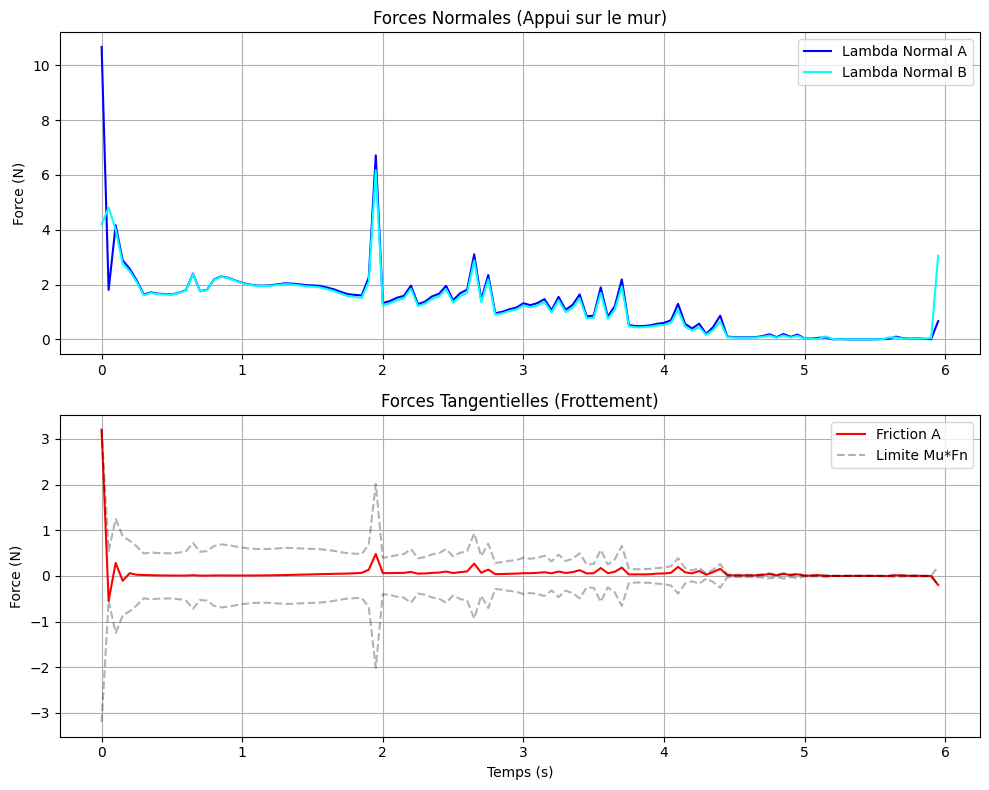

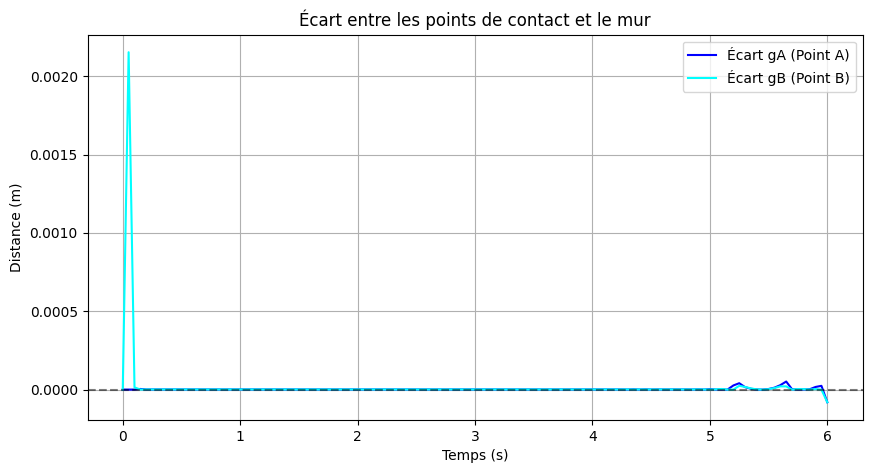

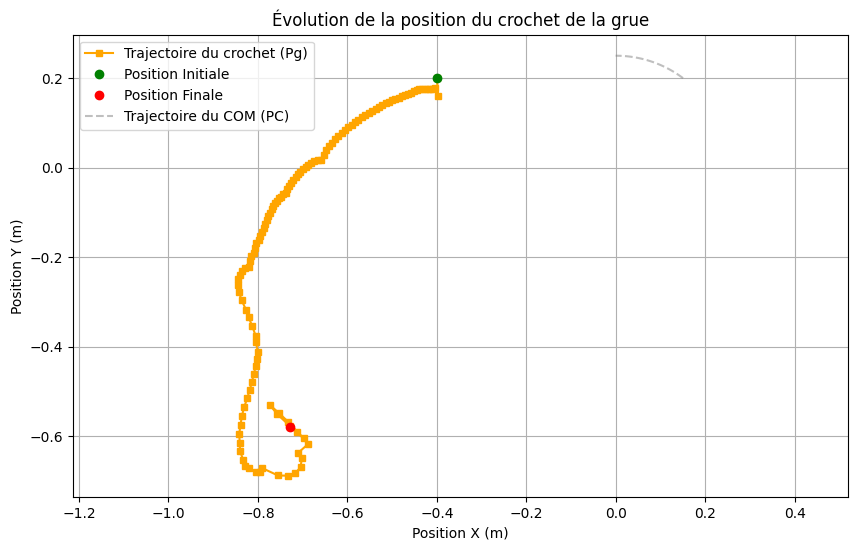

--- Démarrage Phase 2 ---
This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     2888
Number of nonzeros in inequality constraint Jacobian.:     1120
Number of nonzeros in Lagrangian Hessian.............:     3045

Total number of variables............................:      728
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      488
Total number of inequality constraints...............:      400
        inequality constraints with only lower bounds:      320
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       80

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.0625000e+04 1.75e+03 1.00e+02  -1.0 0.00e+0

RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/optistack_internal.cpp:1338: Assertion "return_success(accept_limit)" failed:
Solver failed. You may use opti.debug.value to investigate the latest values of variables. return_status is 'Restoration_Failed'

In [55]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


def corners_world(xC, yC, th, a, b):
    c, s = np.cos(th), np.sin(th)
    R = np.array([[c, -s],
                  [s,  c]])
    corners_b = np.array([
        [-a/2, -b/2],
        [ a/2, -b/2],
        [ a/2,  b/2],
        [-a/2,  b/2]
    ])
    corners_w = (R @ corners_b.T).T + np.array([xC, yC])
    return corners_w

def floor_contact(y_point, v_y_point, k=5e4, d=5e3):
    # g = y_point (la distance au sol y=0)
    # Si y < 0, on applique une force vers le haut
    penetration = ca.fmax(0, -y_point)
    return k * penetration**2 - d * v_y_point * penetration


def solve_ocp_part1():
    a = 0.300   # m
    b = 0.400   # m
    m = 7.0     # kg
    mu = 0.3


    T = 6.0
    dt = 0.05
    N = int(T / dt)
    tgrid = np.linspace(0.0, T, N+1)

    # Wall pivot
    Pw = np.array([0.0, 0.0], dtype=float)

    # Wall rotation law
    phi0 = 0.0
    phiT = np.deg2rad(37.0)
    Omega = (phiT - phi0) / T

    Icom = (m / 12.0) * (a*a + b*b)

    # Points in body frame
    rA_b = np.array([-a/2.0, -b/2.0], dtype=float)
    rB_b = np.array([-a/2.0, +b/2.0], dtype=float)
    rD_b = np.array([-a/2.0,  0.0], dtype=float) 

    # Crane limits
    Tmax = 200.0
    Vg_max = 0.8

    # Hook initial position
    xg0, yg0 = -0.4, 0.2
    xg_min, xg_max = -3.0, 3.0
    yg_min, yg_max = -3.0, 3.0

    # Initial state
    th0 = 0.0
    x0, y0 = a/2, b/2
    vx0, vy0, om0 = 0.0, 0.0, 0.0

    th_goal = th0 + np.deg2rad(37.0)


    opti = ca.Opti()

    xC = opti.variable(N+1)
    yC = opti.variable(N+1)
    th = opti.variable(N+1)
    vx = opti.variable(N+1)
    vy = opti.variable(N+1)
    om = opti.variable(N+1)
    
    lam_nA = opti.variable(N)
    lam_nB = opti.variable(N)
    lam_tA = opti.variable(N)
    lam_tB = opti.variable(N)
    lamn_max = 500.0
    opti.subject_to(lam_nA >= 0)
    opti.subject_to(lam_nB >= 0)

    opti.subject_to(lam_nA <= lamn_max)
    opti.subject_to(lam_nB <= lamn_max)
    
    opti.subject_to(lam_tA <=  mu * lam_nA)
    opti.subject_to(lam_tA >= -mu * lam_nA)
    opti.subject_to(lam_tB <=  mu * lam_nB)
    opti.subject_to(lam_tB >= -mu * lam_nB)

    xg = opti.variable(N+1)
    yg = opti.variable(N+1)
    Tvar = opti.variable(N)

    def Rot(angle):
        c = ca.cos(angle)
        s = ca.sin(angle)
        return ca.vertcat(
            ca.horzcat(c, -s),
            ca.horzcat(s,  c)
        )

    opti.subject_to(xC[0] == x0)
    opti.subject_to(yC[0] == y0)
    opti.subject_to(th[0] == th0)
    opti.subject_to(vx[0] == vx0)
    opti.subject_to(vy[0] == vy0)
    opti.subject_to(om[0] == om0)
    opti.subject_to(xg[0] == xg0)
    opti.subject_to(yg[0] == yg0)

    opti.subject_to(xg >= xg_min)
    opti.subject_to(xg <= xg_max)
    opti.subject_to(yg >= yg_min)
    opti.subject_to(yg <= yg_max)

    opti.subject_to(Tvar >= 0)
    opti.subject_to(Tvar <= Tmax)
    
    opti.subject_to(xC >= -1.0)
    opti.subject_to(xC <=  1.0)
    opti.subject_to(yC >=  0.0)
    opti.subject_to(yC <=  1.2)

    # Hook speed limit
    #Creations de variables à chaque time-step k ? 
    for k in range(N):
        dxg = xg[k+1] - xg[k]
        dyg = yg[k+1] - yg[k]
        opti.subject_to(dxg*dxg + dyg*dyg <= (Vg_max*dt)**2)

    opti.set_initial(xC, x0)
    opti.set_initial(yC, y0)
    opti.set_initial(th, th0)
    opti.set_initial(vx, 0.0)
    opti.set_initial(vy, 0.0)
    opti.set_initial(om, 0.0)

    opti.set_initial(xg, xg0)
    opti.set_initial(yg, yg0)
    # opti.set_initial(Tvar, 30.0)

    J = 0.0

    for k in range(N):
        tk = tgrid[k]
        phi_k = phi0 + Omega * tk

        #vec wall 2
        tvec = ca.vertcat(-ca.sin(phi_k), ca.cos(phi_k))
        nvec = ca.vertcat( ca.cos(phi_k), ca.sin(phi_k))

    
        Rk = Rot(th[k])
        pCk = ca.vertcat(xC[k], yC[k])
        vCk = ca.vertcat(vx[k], vy[k])

        rA_w = Rk @ ca.DM(rA_b)
        rB_w = Rk @ ca.DM(rB_b)
        rD_w = Rk @ ca.DM(rD_b)

        pAk = pCk + rA_w
        pBk = pCk + rB_w
        pDk = pCk + rD_w
        

        
        gA = nvec.T @ (pAk - ca.DM(Pw))
        gB = nvec.T @ (pBk - ca.DM(Pw))
        # opti.subject_to(gA <= eps_g)
        # opti.subject_to(gA >= -eps_g)
        # opti.subject_to(gB <= eps_g)
        # opti.subject_to(gB >= -eps_g)
        opti.subject_to(gA >= 0) 
        opti.subject_to(gB >= 0)
        
        
        # 2. Lien Vitesse / Frottement (Régularisation)
        #  On calcule la vitesse des points A et B le long du mur (tangentielle)
        vA_w = vCk + ca.vertcat(-om[k]*rA_w[1], om[k]*rA_w[0])
        vtA = tvec.T @ vA_w
        vB_w = vCk + ca.vertcat(-om[k]*rB_w[1], om[k]*rB_w[0])
        vtB = tvec.T @ vB_w

        # f_y_sol_A = floor_contact(pAk[1], vA_w[1])
        # f_y_sol_B = floor_contact(pBk[1], vB_w[1])

        # f_x_sol_A = -mu * f_y_sol_A * ca.tanh(vA_w[0] / 0.1)
        # f_x_sol_B = -mu * f_y_sol_B * ca.tanh(vB_w[0] / 0.1)
        
        
        
        # opti.subject_to(lam_tA[k] == -mu * lam_nA[k] * ca.tanh(vtA / 0.1))
        # opti.subject_to(lam_tB[k] == -mu * lam_nB[k] * ca.tanh(vtB / 0.1))


        
        FA = lam_nA[k]*nvec + lam_tA[k]*tvec
        FB = lam_nB[k]*nvec + lam_tB[k]*tvec

        # F_sol_total = ca.vertcat(f_x_sol_B, f_y_sol_B)

        # Rope force from crane, attached at COM
        Pgk = ca.vertcat(xg[k], yg[k])
        dvec = Pgk - pCk
        d = ca.sqrt(dvec[0]**2 + dvec[1]**2 + 1e-9)
        u = dvec / (d + 1e-9)
        Frope = Tvar[k] * u
        

        # # (recommended) avoid Pg ~ PC (direction undefined)
        # dmin = 0.10
        # opti.subject_to((xg[k]-xC[k])**2 + (yg[k]-yC[k])**2 >= dmin**2)

        # --- CONE AT POINT D, around (-n) direction ---
        # Axis of cone is -nvec (opposite wall normal).
        # Components of Frope in (t, -n):
        FnD = (-nvec).T @ Frope
        FtD = ( tvec).T @ Frope

        opti.subject_to(FnD >= 0)
        opti.subject_to(FtD <=  mu * FnD)
        opti.subject_to(FtD >= -mu * FnD)

        # Dynamics
        Fc = Frope + FA + FB

        axk = Fc[0] / m
        ayk = Fc[1] / m

        opti.subject_to(xC[k+1] == xC[k] + dt * vx[k])
        opti.subject_to(yC[k+1] == yC[k] + dt * vy[k])
        opti.subject_to(vx[k+1] == vx[k] + dt * axk)
        opti.subject_to(vy[k+1] == vy[k] + dt * ayk)

        # Torque: since rope applied at COM
        tauA = rA_w[0]*FA[1] - rA_w[1]*FA[0]
        tauB = rB_w[0]*FB[1] - rB_w[1]*FB[0]
        # tau_sol_A = rA_w[0] * f_y_sol_A - rA_w[1] * f_x_sol_A
        # tau_sol_B = rB_w[0] * f_y_sol_B - rB_w[1] * f_x_sol_B
        alphak = (tauA + tauB) / Icom
        
        
        opti.subject_to(th[k+1] == th[k] + dt * om[k])
        opti.subject_to(om[k+1] == om[k] + dt * alphak)
        
        J += 1e6 * (gA**2 + gB**2)
        # J += 1e6 * (gB**2)
        J += 1e4 * (vtA**2+ vtB**2)

    # Terminal cost only
    J += 1e5  * ((th[N]-th_goal)**2)
    J += 1e3  * (vx[N]**2 + vy[N]**2)
    J += 1e3  * (om[N]**2)
    
    opti.subject_to(th[N] == th_goal)
    # opti.subject_to(xC[N] == x_goal)
    # opti.subject_to(yC[N] == y_goal)

    # On veut que le coin bas-droite (celui qui servira de pivot en P2) touche le sol à la fin
    R_final = Rot(th[N])
    pB_final = ca.vertcat(xC[N], yC[N]) + R_final @ ca.DM(np.array([-a/2.0, -b/2.0]))
    opti.subject_to(pB_final[1] == 0)
    
    opti.minimize(J)

    # Solve
    p_opts = {"expand": True}
    s_opts = {
        "max_iter": 4000,
        "tol": 1e-5,
        "acceptable_tol": 1e-5,
        "acceptable_iter": 50,
        "mu_strategy": "adaptive",
        "print_level": 5
    }
    opti.solver("ipopt", p_opts, s_opts)

    sol = opti.solve()
    


    out = {
        "t": tgrid,
        "phi": phi0 + Omega * tgrid,
        "xC": sol.value(xC),
        "yC": sol.value(yC),
        "th": sol.value(th),
        "vx": sol.value(vx),
        "vy": sol.value(vy),
        "om": sol.value(om),
        "xg": sol.value(xg),
        "yg": sol.value(yg),
        "T": sol.value(Tvar),
        "mu": mu,
        "Tmax": Tmax,
        "a": a,
        "b": b,
        "Pw": Pw,
        "th_goal": th_goal,
        # "x_goal": x_goal,
        # "y_goal": y_goal,
    }
    
    
    ######################################### GRAPHS ###################################

    # On récupère les valeurs numériques
    t_f = out["t"][:-1]
    lnA = sol.value(lam_nA)
    lnB = sol.value(lam_nB)
    ltA = sol.value(lam_tA)
    ltB = sol.value(lam_tB)

    # Création d'une figure dédiée aux forces
    fig_forces, axs = plt.subplots(2, 1, figsize=(10, 8))

    # Graphique 1 : Forces Normales
    axs[0].plot(t_f, lnA, label='Lambda Normal A', color='blue')
    axs[0].plot(t_f, lnB, label='Lambda Normal B', color='cyan')
    axs[0].set_ylabel('Force (N)')
    axs[0].set_title('Forces Normales (Appui sur le mur)')
    axs[0].legend()
    axs[0].grid(True)

    # Graphique 2 : Forces Tangentielles vs Limite de Friction
    axs[1].plot(t_f, ltA, label='Friction A', color='red')
    axs[1].plot(t_f, out["mu"] * lnA, '--', color='black', alpha=0.3, label='Limite Mu*Fn')
    axs[1].plot(t_f, -out["mu"] * lnA, '--', color='black', alpha=0.3)
    axs[1].set_ylabel('Force (N)')
    axs[1].set_xlabel('Temps (s)')
    axs[1].set_title('Forces Tangentielles (Frottement)')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show() # <--- Crucial pour bloquer l'exécution et voir le graphe
    
    xC_opt = sol.value(xC)
    yC_opt = sol.value(yC)
    th_opt = sol.value(th)
    phi_opt = out["phi"]

    gA_vals = []
    gB_vals = []

    for k in range(len(phi_opt)):
        # Vecteur normal au mur à l'instant k
        nk = np.array([np.cos(phi_opt[k]), np.sin(phi_opt[k])])
        
        # Rotation de la plaque
        Rk = np.array([[np.cos(th_opt[k]), -np.sin(th_opt[k])],
                    [np.sin(th_opt[k]),  np.cos(th_opt[k])]])
        
        # Position des points A et B en mondial
        pAk = np.array([xC_opt[k], yC_opt[k]]) + Rk @ rA_b
        pBk = np.array([xC_opt[k], yC_opt[k]]) + Rk @ rB_b
        
        # Distance au mur (n' @ (P - Pw))
        gA_vals.append(nk.T @ (pAk - Pw))
        gB_vals.append(nk.T @ (pBk - Pw))

    plt.figure(figsize=(10, 5))
    plt.plot(out["t"], gA_vals, label='Écart gA (Point A)', color='blue')
    plt.plot(out["t"], gB_vals, label='Écart gB (Point B)', color='cyan')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5) # La ligne du mur
    plt.ylabel('Distance (m)')
    plt.xlabel('Temps (s)')
    plt.title('Écart entre les points de contact et le mur')
    plt.legend()
    plt.grid(True)
    plt.show()
    

    xg_vals = sol.value(xg)
    yg_vals = sol.value(yg)
    time_steps = out["t"]

    plt.figure(figsize=(10, 6))
    plt.plot(xg_vals, yg_vals, 's-', label='Trajectoire du crochet (Pg)', color='orange', markersize=4)
    plt.plot(xg_vals[0], yg_vals[0], 'go', label='Position Initiale')
    plt.plot(xg_vals[-1], yg_vals[-1], 'ro', label='Position Finale')

    plt.plot(sol.value(xC), sol.value(yC), '--', label='Trajectoire du COM (PC)', color='gray', alpha=0.5)

    plt.xlabel('Position X (m)')
    plt.ylabel('Position Y (m)')
    plt.title('Évolution de la position du crochet de la grue')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()
    
    return out


def merge_out(o1, o2):
    res = {}
    # Liste des clés à concaténer (états et temps)
    keys = ["t", "phi", "xC", "yC", "th", "vx", "vy", "om", "xg", "yg"]
    for k in keys:
        # On enlève le premier élément de o2 pour éviter le doublon avec le dernier de o1
        res[k] = np.concatenate([o1[k], o2[k][1:]])
    
    # Pour la tension T, la taille est N (pas N+1), on concatène simplement
    res["T"] = np.concatenate([o1["T"], o2["T"]])
    
    # On garde les paramètres physiques de la plaque
    res.update({"a": o1["a"], "b": o1["b"], "Pw": o1["Pw"], "mu": o1["mu"]})
    return res

def smooth_contact(gap, velocity, k, d):
    # On utilise une pénalité quadratique lisse pour la force normale
    # force = k * (enfoncement)^2 - d * vitesse (si enfoncé)
    penetration = ca.fmax(0, -gap)
    return k * penetration**2 - d * velocity * penetration

def solve_ocp_part2(out1):
    opti = ca.Opti()
    
    # --- Paramètres Physiques ---
    a, b, m, mu = out1["a"], out1["b"], 7.0, 0.3
    N = 80 
    Icom = (m / 12.0) * (a**2 + b**2)
    
    # Points dans le repère local du bac
    rA_b = np.array([-a/2.0, +b/2.0]) # Coin "haut" (contre le mur)
    rB_b = np.array([-a/2.0, -b/2.0]) # Coin "bas" (pivot sol/mur)
    rD_b = np.array([+a/2.0, +b/2.0]) # Coin "haut-droit" (attache câble pour levier)

    phi_start_p2 = out1["phi"][-1]
    Omega2 = np.deg2rad(5.0)
    x_goal, y_goal = 0.2, 0.15

    # --- Variables ---
    tf_val = 8.0 
    dt = tf_val / N
    xC = opti.variable(N+1); yC = opti.variable(N+1); th = opti.variable(N+1)
    vx = opti.variable(N+1); vy = opti.variable(N+1); om = opti.variable(N+1)
    xg = opti.variable(N+1); yg = opti.variable(N+1)
    Tvar = opti.variable(N)

    # --- Initialisation (Fin Phase 1) ---
    opti.subject_to(xC[0] == out1["xC"][-1]); opti.subject_to(yC[0] == out1["yC"][-1])
    opti.subject_to(th[0] == out1["th"][-1]); opti.subject_to(vx[0] == out1["vx"][-1])
    opti.subject_to(vy[0] == out1["vy"][-1]); opti.subject_to(om[0] == out1["om"][-1])
    opti.subject_to(xg[0] == out1["xg"][-1]); opti.subject_to(yg[0] == out1["yg"][-1])

    # Aide à la convergence
    opti.set_initial(th, np.linspace(out1["th"][-1], np.pi/2, N+1))
    opti.set_initial(Tvar, 50)

    L_cable_fixe = np.sqrt((out1["xg"][-1] - out1["xC"][-1])**2 + (out1["yg"][-1] - out1["yC"][-1])**2)
    
    f_nA_all, f_nB_all, f_n_sol_B_all = [], [], []

    for k in range(N):
        tk = k * dt
        phi_k = ca.fmin(phi_start_p2 + Omega2 * tk, np.pi/2)
        
        # Cinématique
        Rk = ca.vertcat(ca.horzcat(ca.cos(th[k]), -ca.sin(th[k])), 
                        ca.horzcat(ca.sin(th[k]),  ca.cos(th[k])))
        
        pCk = ca.vertcat(xC[k], yC[k])
        vCk = ca.vertcat(vx[k], vy[k])
        rA_w, rB_w, rD_w = Rk @ rA_b, Rk @ rB_b, Rk @ rD_b
        pAk, pBk, pDk = pCk + rA_w, pCk + rB_w, pCk + rD_w
        vAk = vCk + ca.vertcat(-om[k]*rA_w[1], om[k]*rA_w[0])
        vBk = vCk + ca.vertcat(-om[k]*rB_w[1], om[k]*rB_w[0])

        # --- Forces de Contact (Modèle Ressort-Amortisseur Lisse) ---
        n_mur = ca.vertcat(ca.cos(phi_k), ca.sin(phi_k))
        t_mur = ca.vertcat(-ca.sin(phi_k), ca.cos(phi_k))
        
        gA = n_mur.T @ (pAk - ca.DM(out1["Pw"]))
        gB = n_mur.T @ (pBk - ca.DM(out1["Pw"]))
        
        # k_contact réduit à 5e5 pour la stabilité
        f_nA_k = smooth_contact(gA, (n_mur.T @ vAk), 5e5, 1e4)
        f_nB_k = smooth_contact(gB, (n_mur.T @ vBk), 5e5, 1e4)
        f_n_sol_A_k = smooth_contact(pAk[1], vAk[1], 5e5, 1e4)
        f_n_sol_B_k = smooth_contact(pBk[1], vBk[1], 5e5, 1e4)

        # Frottements (Mur et Sol)
        f_tA = -mu * f_nA_k * ca.tanh((t_mur.T @ vAk) / 0.1)
        f_tB = -mu * f_nB_k * ca.tanh((t_mur.T @ vBk) / 0.1)
        f_t_sol_A = -mu * f_n_sol_A_k * ca.tanh(vAk[0] / 0.1)
        f_t_sol_B = -mu * f_n_sol_B_k * ca.tanh(vBk[0] / 0.1)

        # Vecteurs forces totaux aux points A et B (Somme Mur + Sol)
        FA = f_tA * t_mur + ca.vertcat(f_t_sol_A, f_n_sol_A_k)
        FB = f_tB * t_mur + ca.vertcat(f_t_sol_B, f_n_sol_B_k)
        
        # --- Câble de la grue ---
        Pgk = ca.vertcat(xg[k], yg[k])
        dvec = Pgk - pDk # Force appliquée au point D (coin), pas au COM !
        dist_rope = ca.sqrt(ca.sumsqr(dvec) + 1e-6)
        Frope = Tvar[k] * (dvec / dist_rope)

        # --- Dynamique Translation ---
        opti.subject_to(xC[k+1] == xC[k] + dt*vx[k])
        opti.subject_to(yC[k+1] == yC[k] + dt*vy[k])
        opti.subject_to(vx[k+1] == vx[k] + dt * (FA[0] + FB[0] + Frope[0]) / m)
        opti.subject_to(vy[k+1] == vy[k] + dt * ((FA[1] + FB[1] + Frope[1]) / m))

        # --- Dynamique Rotation (Torques) ---
        # On calcule les moments par rapport au COM
        tauA = rA_w[0] * FA[1] - rA_w[1] * FA[0]
        tauB = rB_w[0] * FB[1] - rB_w[1] * FB[0]
        
        opti.subject_to(th[k+1] == th[k] + dt*om[k])
        opti.subject_to(om[k+1] == om[k] + dt * (tauA + tauB) / Icom)

        # --- Contraintes géométriques "dures" ---
        opti.subject_to(gA >= 0)
        opti.subject_to(gB >= 0)
        opti.subject_to(pAk[1] >= 0)
        opti.subject_to(pBk[1] >= 0)
        
        # Limite vitesse grue
        opti.subject_to(ca.sumsqr(ca.vertcat(xg[k+1]-xg[k], yg[k+1]-yg[k])) <= (0.3*dt)**2)

    # --- Objectifs ---
    J = 1e6 * (th[N] - np.pi/2)**2 + 1e4 * ((xC[N]-x_goal)**2 + (yC[N]-y_goal)**2)
    J += 1e-1 * ca.sumsqr(Tvar) # Minimiser la tension inutile
    
    opti.minimize(J)
    opti.solver("ipopt", {"expand": True}, {"max_iter": 2000, "tol": 1e-3})
    
    sol = opti.solve()

    # Extraction pour retour
    return {
        "t": np.linspace(out1["t"][-1], out1["t"][-1] + tf_val, N+1), 
        "phi": np.minimum(phi_start_p2 + Omega2 * np.linspace(0, tf_val, N+1), np.pi/2),
        "xC": sol.value(xC), "yC": sol.value(yC), "th": sol.value(th),
        "xg": sol.value(xg), "yg": sol.value(yg), "T": sol.value(Tvar),
        "a": a, "b": b, "Pw": out1["Pw"], "mu": mu, 
        "vx": sol.value(vx), "vy": sol.value(vy), "om": sol.value(om)
    }

def animate_plate_wall_with_crane(out, wall_half_length=1.0, save_path=None, fps=20):
    a = out["a"]
    b = out["b"]
    Pw = np.array(out["Pw"], dtype=float)

    t = out["t"]
    xC = out["xC"]
    yC = out["yC"]
    th = out["th"]
    phi = out["phi"]

    xg = out["xg"]
    yg = out["yg"]
    Tvar = out["T"]

    fig, ax = plt.subplots()
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)

    margin = 0.4
    xmin = min(np.min(xC), np.min(xg), Pw[0]) - wall_half_length - margin
    xmax = max(np.max(xC), np.max(xg), Pw[0]) + wall_half_length + margin
    ymin = min(np.min(yC), np.min(yg), Pw[1]) - wall_half_length - margin
    ymax = max(np.max(yC), np.max(yg), Pw[1]) + wall_half_length + margin
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    
    # Optionnel : Dessiner le sol pour mieux voir le pivot
    ax.axhline(0, color='brown', lw=2, zorder=0)

    wall_line, = ax.plot([], [], linewidth=2, label="Pivoting wall")
    plate_patch, = ax.plot([], [], linewidth=2, label="Crate")
    com_point, = ax.plot([], [], marker="o", markersize=5, label="COM")
    hook_point, = ax.plot([], [], marker="s", markersize=6, linestyle="None", label="Hook Pg")
    rope_line, = ax.plot([], [], linewidth=1.5, label="Rope")

    force_scale = 0.01
    F_rope_arrow = ax.quiver([], [], [], [], angles="xy", scale_units="xy", scale=1, label="Rope force (scaled)")

    Pw_point, = ax.plot([Pw[0]], [Pw[1]], marker="x", markersize=8, linestyle="None", label="Wall pivot")
    time_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top")
    ax.legend(loc="lower left")

    def init():
        wall_line.set_data([], [])
        plate_patch.set_data([], [])
        com_point.set_data([], [])
        hook_point.set_data([], [])
        rope_line.set_data([], [])
        F_rope_arrow.set_offsets(np.array([[0.0, 0.0]]))
        F_rope_arrow.set_UVC(np.array([0.0]), np.array([0.0]))
        time_text.set_text("")
        return (wall_line, plate_patch, com_point, hook_point, Pw_point, rope_line, F_rope_arrow, time_text)

    def update(k):
        tvec = np.array([-np.sin(phi[k]), np.cos(phi[k])])
        L = wall_half_length
        svals = np.linspace(0.0, L, 2)
        wall_pts = Pw[None, :] + svals[:, None] * tvec[None, :]
        wall_line.set_data(wall_pts[:, 0], wall_pts[:, 1])

        C = corners_world(xC[k], yC[k], th[k], a, b)
        poly = np.vstack([C, C[0]])
        plate_patch.set_data(poly[:, 0], poly[:, 1])

        com_point.set_data([xC[k]], [yC[k]])
        hook_point.set_data([xg[k]], [yg[k]])
        rope_line.set_data([xC[k], xg[k]], [yC[k], yg[k]])

        Tk = Tvar[k] if k < len(t)-1 else Tvar[-1]
        dvec = np.array([xg[k] - xC[k], yg[k] - yC[k]])
        dn = np.linalg.norm(dvec) + 1e-9
        u = dvec / dn
        Fxy = Tk * u

        F_rope_arrow.set_offsets(np.array([[xC[k], yC[k]]]))
        F_rope_arrow.set_UVC(np.array([force_scale * Fxy[0]]),
                             np.array([force_scale * Fxy[1]]))

        time_text.set_text(
            f"t = {t[k]:.2f} s\n"
            f"theta = {th[k]:.3f} rad\n"
            f"phi = {phi[k]:.3f} rad\n"
            f"T = {Tk:.1f} N"
        )

        return (wall_line, plate_patch, com_point, hook_point, Pw_point, rope_line, F_rope_arrow, time_text)

    anim = FuncAnimation(fig, update, frames=len(t), init_func=init, blit=False, interval=int(1000 / fps))

    if save_path is not None:
        if save_path.lower().endswith(".gif"):
            anim.save(save_path, writer="pillow", fps=fps)
        elif save_path.lower().endswith(".mp4"):
            anim.save(save_path, writer="ffmpeg", fps=fps)
        else:
            raise ValueError("save_path must end with .gif or .mp4")
        print(f"Animation saved: {save_path}")
    else:
        plt.show()

    return anim

def plot_contact_forces_p2(out2):
    t = out2["t"][:-1] # N points
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(t, out2["f_nA"], label="Force Normale Mur A")
    plt.plot(t, out2["f_nB"], label="Force Normale Mur B")
    plt.ylabel("Force (N)")
    plt.title("Forces de Contact avec le MUR")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(2, 1, 2)
    plt.plot(t, out2["f_n_sol_B"], color='r', label="Force Normale Sol B")
    plt.ylabel("Force (N)")
    plt.xlabel("Temps (s)")
    plt.title("Force de Contact avec le SOL")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


def solve_full_mission():
    print("--- Démarrage Phase 1 ---")
    out1 = solve_ocp_part1() 
    
    print("--- Démarrage Phase 2 ---")
    out2 = solve_ocp_part2(out1)
    
    # Visualisation des forces de la phase 2
    plot_contact_forces_p2(out2)
    
    out_total = merge_out(out1, out2)
    return out_total

if __name__ == "__main__":
    # 1. On lance la mission complète
    out = solve_full_mission()
    
    # 2. On lance l'animation sur le résultat fusionné
    # Note: L'animation va maintenant durer T1 + T2 (6s + 4s = 10s)
    animate_plate_wall_with_crane(out, save_path="mission_complete.gif", fps=20)
    
    # 3. Prints de debug
    print("\nMission terminée avec succès !")
    print(f"Max Tension: {np.max(out['T']):.1f} N")
    print(f"Position Finale COM: ({out['xC'][-1]:.3f}, {out['yC'][-1]:.3f})")
    print(f"Angle Final: {np.rad2deg(out['th'][-1]):.1f}°")


In [1]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


def corners_world(xC, yC, th, a, b):
    c, s = np.cos(th), np.sin(th)
    R = np.array([[c, -s],
                  [s,  c]])
    corners_b = np.array([
        [-a/2, -b/2],
        [ a/2, -b/2],
        [ a/2,  b/2],
        [-a/2,  b/2]
    ])
    corners_w = (R @ corners_b.T).T + np.array([xC, yC])
    return corners_w

#elastic contact system (not used)
def floor_contact(y_point, v_y_point, k=5e4, d=5e3):
    #If y < 0, an upward force is applied.
    penetration = ca.fmax(0, -y_point)
    
    return k * penetration**2 - d * v_y_point * penetration

def solve_ocp_part1():
    a = 0.300   # m
    b = 0.400   # m
    m = 7.0     # kg
    mu = 0.3

    T = 6.0
    dt = 0.05
    N = int(T / dt)
    tgrid = np.linspace(0.0, T, N+1)

    # Wall pivot position 
    Pw = np.array([0.0, 0.0], dtype=float)
    
    # Wall rotation law
    phi0 = 0.0
    phiT = np.deg2rad(37.0)
    Omega = (phiT - phi0) / T #constant speed
    
    Icom = (m / 12.0) * (a*a + b*b)

    # Points in body frame
    # rA_b = np.array([-a/2.0, -b/2.0], dtype=float)
    rA_b = np.array([0.0, 0.0], dtype=float)
    # rB_b = np.array([-a/2.0, +b/2.0], dtype=float)
    rB_b = np.array([0.0, +b], dtype=float)
    rD_b = np.array([-a/2.0,  0.0], dtype=float)

    # Crane limits
    Tmax = 200.0
    Vg_max = 0.8

    # Hook initial position
    xg0, yg0 = -0.4, 0.2
    xg_min, xg_max = -3.0, 3.0
    yg_min, yg_max = -3.0, 3.0

    # Initial state
    th0 = 0.0
    x0, y0 = a/2, b/2
    vx0, vy0, om0 = 0.0, 0.0, 0.0

    #Final objective 
    th_goal = th0 + np.deg2rad(37.0)
    x_goal = 0.2
    y_goal = 0.15

    #Casadi solver 
    opti = ca.Opti()

    xC = opti.variable(N+1)
    yC = opti.variable(N+1)
    th = opti.variable(N+1)
    vx = opti.variable(N+1)
    vy = opti.variable(N+1)
    om = opti.variable(N+1)

    lam_nA = opti.variable(N)
    lam_nB = opti.variable(N)
    lam_tA = opti.variable(N)
    lam_tB = opti.variable(N)
    lamn_max = 500.0
    opti.subject_to(lam_nA >= 0)
    opti.subject_to(lam_nB >= 0)
    opti.subject_to(lam_nA <= lamn_max)
    opti.subject_to(lam_nB <= lamn_max)

    opti.subject_to(lam_tA <=  mu * lam_nA)
    opti.subject_to(lam_tA >= -mu * lam_nA)
    opti.subject_to(lam_tB <=  mu * lam_nB)
    opti.subject_to(lam_tB >= -mu * lam_nB)

    #Additional variables of the crane
    xg = opti.variable(N+1)
    yg = opti.variable(N+1)
    Tvar = opti.variable(N)

    #rot mat
    def Rot(angle):
        c = ca.cos(angle)
        s = ca.sin(angle)
        return ca.vertcat(
            ca.horzcat(c, -s),
            ca.horzcat(s,  c)
        )

    #Constraints
    opti.subject_to(xC[0] == x0)
    opti.subject_to(yC[0] == y0)
    opti.subject_to(th[0] == th0)
    opti.subject_to(vx[0] == vx0)
    opti.subject_to(vy[0] == vy0)
    opti.subject_to(om[0] == om0)
    opti.subject_to(xg[0] == xg0)
    opti.subject_to(yg[0] == yg0)
    
    opti.subject_to(xC >= -1.0)
    opti.subject_to(xC <=  1.0)
    opti.subject_to(yC >=  0.0)
    opti.subject_to(yC <=  1.2)

    opti.subject_to(xg >= xg_min)
    opti.subject_to(xg <= xg_max)
    opti.subject_to(yg >= yg_min)
    opti.subject_to(yg <= yg_max)

    opti.subject_to(Tvar >= 0)
    opti.subject_to(Tvar <= Tmax)
    



    # Hook speed limit
    for k in range(N):
        dxg = xg[k+1] - xg[k]
        dyg = yg[k+1] - yg[k]
        opti.subject_to(dxg*dxg + dyg*dyg <= (Vg_max*dt)**2)

    #Guesses
    opti.set_initial(xC, x0)
    opti.set_initial(yC, y0)
    opti.set_initial(th, th0)
    opti.set_initial(vx, 0.0)
    opti.set_initial(vy, 0.0)
    opti.set_initial(om, 0.0)
    opti.set_initial(xg, xg0)
    opti.set_initial(yg, yg0)
    # opti.set_initial(Tvar, 30.0)

    opti.subject_to(th[N] == th_goal)
        
    # We want the bottom left corner to touch the ground at the end.
    R_final = Rot(th[N])
    pB_final = ca.vertcat(xC[N], yC[N]) + R_final @ ca.DM(np.array([-a/2.0, -b/2.0]))
    opti.subject_to(pB_final[1] == 0)

    J = 0.0

    for k in range(N):
        tk = tgrid[k]
        phi_k = phi0 + Omega * tk

        #vec pivoting wall
        tvec = ca.vertcat(-ca.sin(phi_k), ca.cos(phi_k))
        nvec = ca.vertcat( ca.cos(phi_k), ca.sin(phi_k))

        Rk = Rot(th[k])
        pCk = ca.vertcat(xC[k], yC[k])
        vCk = ca.vertcat(vx[k], vy[k])

        #Position of A,B,D in the world
        rA_w = Rk @ ca.DM(rA_b)
        rB_w = Rk @ ca.DM(rB_b)
        rD_w = Rk @ ca.DM(rD_b)
        pAk = pCk + rA_w
        pBk = pCk + rB_w
        pDk = pCk + rD_w

        #gap between the pivoting wall and the crate at A & B
        gA = nvec.T @ (pAk - ca.DM(Pw))
        gB = nvec.T @ (pBk - ca.DM(Pw))
        
        #Soft vs hard constraints
        opti.subject_to(gA >= 0)
        opti.subject_to(gB >= 0)
        opti.subject_to(pAk[1] >= 0)
        opti.subject_to(pBk[1] >= 0)
        # opti.subject_to(gA <= eps_g)
        # opti.subject_to(gA >= -eps_g)
        # opti.subject_to(gB <= eps_g)
        # opti.subject_to(gB >= -eps_g)

        # speed of points A and B along the wall
        vA_w = vCk + ca.vertcat(-om[k]*rA_w[1], om[k]*rA_w[0])
        vtA = tvec.T @ vA_w
        vB_w = vCk + ca.vertcat(-om[k]*rB_w[1], om[k]*rB_w[0])
        vtB = tvec.T @ vB_w

        #Constraints for elastic model (not used)
        # tanh(v/vs) is a differentiable approximation of sign(v) to stabilise the optimisation
        # vs=0.1 sets the area where the transition takes place
        # f_y_sol_A = floor_contact(pAk[1], vA_w[1])
        # f_y_sol_B = floor_contact(pBk[1], vB_w[1])
        # f_x_sol_A = -mu * f_y_sol_A * ca.tanh(vA_w[0] / 0.1)
        # f_x_sol_B = -mu * f_y_sol_B * ca.tanh(vB_w[0] / 0.1)
        # opti.subject_to(lam_tA[k] == -mu * lam_nA[k] * ca.tanh(vtA / 0.1))
        # opti.subject_to(lam_tB[k] == -mu * lam_nB[k] * ca.tanh(vtB / 0.1))
        
        # F_sol_total_A = ca.vertcat(f_x_sol_A, f_y_sol_A)
        # F_sol_total_B = ca.vertcat(f_x_sol_B, f_y_sol_B)

        FA = lam_nA[k]*nvec + lam_tA[k]*tvec
        FB = lam_nB[k]*nvec + lam_tB[k]*tvec

        # Rope force from crane, attached at COM
        Pgk = ca.vertcat(xg[k], yg[k])
        dvec = Pgk - pCk #vector
        d = ca.sqrt(dvec[0]**2 + dvec[1]**2 + 1e-9) # additional 1e-9 to avoid /0 & sqrt(0)
        u = dvec / (d + 1e-9) #unit vector
        Frope = Tvar[k] * u
        dmin = 0.05
        opti.subject_to(ca.sumsqr(dvec) >= dmin**2)



        # Dynamics - forces

        Fc = Frope + FA + FB
        axk = Fc[0] / m
        ayk = Fc[1] / m

        opti.subject_to(xC[k+1] == xC[k] + dt * vx[k])
        opti.subject_to(yC[k+1] == yC[k] + dt * vy[k])
        opti.subject_to(vx[k+1] == vx[k] + dt * axk)
        opti.subject_to(vy[k+1] == vy[k] + dt * ayk)
        
        #Dynamics - Torques around COM
        tauA = rA_w[0]*FA[1] - rA_w[1]*FA[0]
        tauB = rB_w[0]*FB[1] - rB_w[1]*FB[0]
        alphak = (tauA + tauB) / Icom

        opti.subject_to(th[k+1] == th[k] + dt * om[k])
        opti.subject_to(om[k+1] == om[k] + dt * alphak)

        #cost function
        J += 1e6 * (gA**2 + gB**2) #gap between the pivoting wall and the crate to be 0 until 37° of rotation 
        J += 1e4 * (vtA**2+ vtB**2) # tangantial velocity to be 0 during the rotation until 37° of rotation. 
        
        #Calm the crane's behaviour change in intensity and velocity
        if k >= 1:
            J += 1e-1 * (Tvar[k] - Tvar[k-1])**2
            dxg = (xg[k] - xg[k-1]) / dt
            dyg = (yg[k] - yg[k-1]) / dt
            J += 1e2 * dxg**2 + 1e2 * dyg**2


    # Terminal cost function
    # J += 1e5  * ((th[N]-th_goal)**2) #already in the constraints
    J += 1e3  * (om[N]**2) #final angular velocity to be 0 

   
   
   


    opti.minimize(J)
    p_opts = {"expand": True}
    s_opts = {
        "max_iter": 4000,
        "tol": 1e-2,
        "acceptable_tol": 1e-2,
        "acceptable_iter": 50,
        "mu_strategy": "adaptive",
        "print_level": 5
    }
    opti.solver("ipopt", p_opts, s_opts)
    sol = opti.solve()


    out = {
        "t": tgrid,
        "phi": phi0 + Omega * tgrid,
        "xC": sol.value(xC),
        "yC": sol.value(yC),
        "th": sol.value(th),
        "vx": sol.value(vx),
        "vy": sol.value(vy),
        "om": sol.value(om),
        "xg": sol.value(xg),
        "yg": sol.value(yg),
        "T": sol.value(Tvar),
        "mu": mu,
        "Tmax": Tmax,
        "a": a,
        "b": b,
        "Pw": Pw,
        "th_goal": th_goal,

    }


    ######################################### GRAPHS ###################################


    t_f = out["t"][:-1]
    lnA = sol.value(lam_nA)
    lnB = sol.value(lam_nB)
    ltA = sol.value(lam_tA)
    ltB = sol.value(lam_tB)
    fig_forces, axs = plt.subplots(2, 1, figsize=(10, 8))

    axs[0].plot(t_f, lnA, label='Lambda Normal A', color='blue')
    axs[0].plot(t_f, lnB, label='Lambda Normal B', color='cyan')
    axs[0].set_ylabel('Force (N)')
    axs[0].set_title('Forces Normales (Appui sur le mur)')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(t_f, ltA, label='Friction A', color='red')
    axs[1].plot(t_f, out["mu"] * lnA, '--', color='black', alpha=0.3, label='Limite Mu*Fn')
    axs[1].plot(t_f, -out["mu"] * lnA, '--', color='black', alpha=0.3)
    axs[1].set_ylabel('Force (N)')
    axs[1].set_xlabel('Temps (s)')
    axs[1].set_title('Forces Tangentielles (Frottement)')
    axs[1].legend()
    axs[1].grid(True)
    plt.tight_layout()
    plt.show()

    xC_opt = sol.value(xC)
    yC_opt = sol.value(yC)
    th_opt = sol.value(th)
    phi_opt = out["phi"]
    gA_vals = []
    gB_vals = []

    for k in range(len(phi_opt)):
        nk = np.array([np.cos(phi_opt[k]), np.sin(phi_opt[k])])

        Rk = np.array([[np.cos(th_opt[k]), -np.sin(th_opt[k])],
                    [np.sin(th_opt[k]),  np.cos(th_opt[k])]])

        pAk = np.array([xC_opt[k], yC_opt[k]]) + Rk @ rA_b
        pBk = np.array([xC_opt[k], yC_opt[k]]) + Rk @ rB_b

        gA_vals.append(nk.T @ (pAk - Pw))
        gB_vals.append(nk.T @ (pBk - Pw))

    plt.figure(figsize=(10, 5))
    plt.plot(out["t"], gA_vals, label='Écart gA (Point A)', color='blue')
    plt.plot(out["t"], gB_vals, label='Écart gB (Point B)', color='cyan')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5) # La ligne du mur
    plt.ylabel('Distance (m)')
    plt.xlabel('Temps (s)')
    plt.title('Écart entre les points de contact et le mur')
    plt.legend()
    plt.grid(True)
    plt.show()


    xg_vals = sol.value(xg)
    yg_vals = sol.value(yg)
    time_steps = out["t"]
    plt.figure(figsize=(10, 6))
    plt.plot(xg_vals, yg_vals, 's-', label='Trajectoire du crochet (Pg)', color='orange', markersize=4)
    plt.plot(xg_vals[0], yg_vals[0], 'go', label='Position Initiale')
    plt.plot(xg_vals[-1], yg_vals[-1], 'ro', label='Position Finale')
    plt.plot(sol.value(xC), sol.value(yC), '--', label='Trajectoire du COM (PC)', color='gray', alpha=0.5)
    plt.xlabel('Position X (m)')
    plt.ylabel('Position Y (m)')
    plt.title('Évolution de la position du crochet de la grue')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()
    return out


def merge_out(o1, o2):
    res = {}
    keys = ["t", "phi", "xC", "yC", "th", "vx", "vy", "om", "xg", "yg"]
    for k in keys:
        res[k] = np.concatenate([o1[k], o2[k][1:]])
    res["T"] = np.concatenate([o1["T"], o2["T"]])
    res.update({"a": o1["a"], "b": o1["b"], "Pw": o1["Pw"], "mu": o1["mu"]})

    return res


    
def smooth_contact(gap, velocity, k=2e4, d=1e3):
    eps = 1e-4
    penetration = 0.5 * (-gap + ca.sqrt(gap**2 + eps))
    return k * penetration**2 - d * velocity * penetration


def solve_ocp_part2(out1):

    opti = ca.Opti()

    a, b = out1["a"], out1["b"]
    m = 7.0
    mu = 0.3
    Icom = (m/12)*(a*a + b*b)

    N = 80
    tf = 8.0
    dt = tf / N

    #constant speed until the end of the rotation 
    phi_start = out1["phi"][-1]
    Omega = np.deg2rad(5.0)

    x_goal = 0.2
    y_goal = 0.15

    Pw = out1["Pw"]

    rA_b = np.array([-a/2,  -b/2])
    rB_b = np.array([-a/2, +b/2])

    xC = opti.variable(N+1)
    yC = opti.variable(N+1)
    th = opti.variable(N+1)
    vx = opti.variable(N+1)
    vy = opti.variable(N+1)
    om = opti.variable(N+1)

    xg = opti.variable(N+1)
    yg = opti.variable(N+1)
    Tvar = opti.variable(N)

    f_nA = opti.variable(N)
    f_nB = opti.variable(N)
    f_n_sol_A = opti.variable(N)
    f_n_sol_B = opti.variable(N)
    
    #slack
    sA = opti.variable(N)
    sB = opti.variable(N)
    opti.subject_to(sA >= 0)
    opti.subject_to(sB >= 0)
    
    #max speed crane
    Vg_max = 0.8 
    for k in range(N):
        dxg = xg[k+1] - xg[k]
        dyg = yg[k+1] - yg[k]
        opti.subject_to(dxg*dxg + dyg*dyg <= (Vg_max*dt)**2)

    opti.subject_to(f_nA >= 0)
    opti.subject_to(f_nB >= 0)
    opti.subject_to(f_n_sol_A >= 0)
    opti.subject_to(f_n_sol_B >= 0)
    
    opti.subject_to(opti.bounded(-3.0, vx, 3.0))
    opti.subject_to(opti.bounded(-3.0, vy, 3.0))
    opti.subject_to(opti.bounded(0.0, yC, 2.0)) 
    opti.subject_to(opti.bounded(0.0, Tvar, 400.0))

    opti.subject_to(xC[0] == out1["xC"][-1])
    opti.subject_to(yC[0] == out1["yC"][-1])
    opti.subject_to(th[0] == out1["th"][-1])
    opti.subject_to(vx[0] == out1["vx"][-1])
    opti.subject_to(vy[0] == out1["vy"][-1])
    opti.subject_to(om[0] == out1["om"][-1])
    opti.subject_to(xg[0] == out1["xg"][-1])
    opti.subject_to(yg[0] == out1["yg"][-1])
    
    # --- Initial guess from phase 1 end (important!) ---
    opti.set_initial(xC, out1["xC"][-1])
    opti.set_initial(yC, out1["yC"][-1])
    opti.set_initial(vx, out1["vx"][-1])
    opti.set_initial(vy, out1["vy"][-1])
    opti.set_initial(om, out1["om"][-1])

    opti.set_initial(xg, out1["xg"][-1])
    opti.set_initial(yg, out1["yg"][-1])
    opti.set_initial(Tvar, out1["T"][-1])


    opti.set_initial(th, np.linspace(out1["th"][-1], np.pi/2, N+1))
    opti.set_initial(f_nA, 50.0)
    opti.set_initial(f_nB, 50.0)
    opti.set_initial(f_n_sol_A, 20.0)
    opti.set_initial(f_n_sol_B, 0.0)

    #vec com--> crane
    dx0 = out1["xg"][-1] - out1["xC"][-1]
    dy0 = out1["yg"][-1] - out1["yC"][-1]
    L = np.sqrt(dx0**2 + dy0**2)
    
    for k in range(N+1):
        opti.set_initial(xg[k], out1["xC"][-1] + dx0)
        opti.set_initial(yg[k], out1["yC"][-1] + dy0)


    FMAX = 200.0
    opti.subject_to(f_nA <= FMAX)
    opti.subject_to(f_nB <= FMAX)
    opti.subject_to(f_n_sol_A <= FMAX)
    opti.subject_to(f_n_sol_B <= FMAX)
    
    #Final position objective
    # opti.subject_to(xC[N] == x_goal)
    # opti.subject_to(yC[N] == y_goal)
    # opti.subject_to(th[N] == np.pi/2)
    # opti.subject_to(om[N] == 0)
    # opti.subject_to(vx[N] == 0)
    # opti.subject_to(vy[N] == 0)



    J = 0

    for k in range(N):

        phi_k = phi_start + Omega * k * dt

        Rk = ca.vertcat(
            ca.horzcat(ca.cos(th[k]), -ca.sin(th[k])),
            ca.horzcat(ca.sin(th[k]),  ca.cos(th[k]))
        )

        pCk = ca.vertcat(xC[k], yC[k])
        vCk = ca.vertcat(vx[k], vy[k])

        rA_w = Rk @ ca.DM(rA_b)
        rB_w = Rk @ ca.DM(rB_b)

        pAk = pCk + rA_w
        pBk = pCk + rB_w

        vAk = vCk + ca.vertcat(-om[k]*rA_w[1], om[k]*rA_w[0])
        vBk = vCk + ca.vertcat(-om[k]*rB_w[1], om[k]*rB_w[0])

        n = ca.vertcat(ca.cos(phi_k), ca.sin(phi_k))
        t = ca.vertcat(-ca.sin(phi_k), ca.cos(phi_k))

        gA = n.T @ (pAk - ca.DM(Pw))
        gB = n.T @ (pBk - ca.DM(Pw))

        # opti.subject_to(gA >= -1e-3) 
        # opti.subject_to(gB >= -1e-3)
        # opti.subject_to(pAk[1] >= -1e-3)
        # opti.subject_to(pBk[1] >= -1e-3)
        eps = 2e-4
        # opti.subject_to(gA >= -eps)
        # opti.subject_to(gB >= -eps)
        
        opti.subject_to(gA + sA[k] >= -1e-4) #Slack
        opti.subject_to(gB + sB[k] >= -1e-4)
        opti.subject_to(pAk[1] >= -eps)
        opti.subject_to(pBk[1] >= -eps)

        # Relaxed complementarity, only pushing 
        opti.subject_to(f_nA[k] >= 0)
        opti.subject_to(f_nB[k] >= 0)
        opti.subject_to(f_n_sol_A[k] >= 0)
        opti.subject_to(f_n_sol_B[k] >= 0)
        
        # friction
        f_tA = -mu * f_nA[k] * ca.tanh((t.T @ vAk)/0.1)
        f_tB = -mu * f_nB[k] * ca.tanh((t.T @ vBk)/0.1)
        f_t_sol_A = -mu * f_n_sol_A[k] * ca.tanh(vAk[0]/0.1)
        f_t_sol_B = -mu * f_n_sol_B[k] * ca.tanh(vBk[0]/0.1)
        # f_tA = -mu * f_nA[k] 
        # f_tB = -mu * f_nB[k] 
        # f_t_sol_A = -mu * f_n_sol_A[k] 
        # f_t_sol_B = -mu * f_n_sol_B[k] 


        FA = f_nA[k]*n + f_tA*t
        FB = f_nB[k]*n + f_tB*t
        FsolA = ca.vertcat(f_t_sol_A, f_n_sol_A[k])
        FsolB = ca.vertcat(f_t_sol_B, f_n_sol_B[k])

        # rope
        dvec = ca.vertcat(xg[k], yg[k]) - pCk
        d    = ca.sqrt(ca.sumsqr(dvec) + 1e-6)     
        u    = dvec / (d + 1e-6)  
        Frope = Tvar[k] * u
        
        if k == 0:
            GA = gA
            GB = gB
            YA = pAk[1]
            YB = pBk[1]
            DD = d
        else:
            GA = ca.vertcat(GA, gA)
            GB = ca.vertcat(GB, gB)
            YA = ca.vertcat(YA, pAk[1])
            YB = ca.vertcat(YB, pBk[1])
            DD = ca.vertcat(DD, d)
            
        
        # dvec = ca.vertcat(xg[k], yg[k]) - pCk
        # J += 1e4 * (ca.sumsqr(dvec) - L**2)**2
        # Frope = Tvar[k] * dvec / L
        

        Fc = Frope + FA + FB + FsolA + FsolB


        opti.subject_to(xC[k+1] == xC[k] + dt*vx[k])
        opti.subject_to(yC[k+1] == yC[k] + dt*vy[k])
        opti.subject_to(vx[k+1] == vx[k] + dt*Fc[0]/m)
        opti.subject_to(vy[k+1] == vy[k] + dt*Fc[1]/m)

        tauA = rA_w[0]*FA[1] - rA_w[1]*FA[0]
        tauB = rB_w[0]*FB[1] - rB_w[1]*FB[0]
        tauSolA = rA_w[0]*FsolA[1] - rA_w[1]*FsolA[0]
        tauSolB = rB_w[0]*FsolB[1] - rB_w[1]*FsolB[0]

        opti.subject_to(th[k+1] == th[k] + dt * om[k])
        opti.subject_to(om[k+1] == om[k] + dt * (tauA + tauB + tauSolA + tauSolB) / Icom)
        
        #complementarity rule bewteen the wall/ground and the crate
        J += 1e3 * (f_nA[k]*gA)**2
        J += 1e3 * (f_nB[k]*gB)**2
        J += 1e3 * (f_n_sol_A[k]*pAk[1])**2
        J += 1e3 * (f_n_sol_B[k]*pBk[1])**2
        
        
        #Calm the crane's behaviour but after the 5 first iterations
        if k > 5:
            J += 1e-1 * (Tvar[k] - Tvar[k-1])**2
            dxg = (xg[k] - xg[k-1]) / dt
            dyg = (yg[k] - yg[k-1]) / dt
            J += 1e2 * dxg**2 + 1e2 * dyg**2
            


    J += 1e5*(xC[N]-x_goal)**2
    J += 1e5*(yC[N]-y_goal)**2
    J += 1e4*(th[N]-np.pi/2)**2
    J += 1e3*(vx[N]**2 + vy[N]**2 + om[N]**2)
    J += 1e8 * ca.sumsqr(sA) + 1e8 * ca.sumsqr(sB)

    
    


    opti.minimize(J)

    opti.solver("ipopt", {"expand":True},
                {"max_iter":5000, "tol":1e-3})

    try:
        sol = opti.solve()

    except RuntimeError as e:
        print("\n--- DEBUG INFEASIBILITY (Phase 2) ---")
        print("Return status:", opti.debug.return_status())

        # helpers
        def min_init(expr):
            return float(np.min(opti.debug.value(expr, opti.initial())))
        def min_last(expr):
            return float(np.min(opti.debug.value(expr)))  # last iterate

        # slack stats
        print("min sA:", float(np.min(opti.debug.value(sA, opti.initial()))),
            "max sA:", float(np.max(opti.debug.value(sA, opti.initial()))))
        print("min sB:", float(np.min(opti.debug.value(sB, opti.initial()))),
            "max sB:", float(np.max(opti.debug.value(sB, opti.initial()))))

        # --- INIT (your initial guess) ---
        # print("\n--- INIT (initial guess) ---")
        # print("min gA:", min_init(GA))
        # print("min gB:", min_init(GB))
        # print("min yA:", min_init(YA))
        # print("min yB:", min_init(YB))
        # print("min rope dist d:", min_init(DD))
        # print("T range init:",
        #     float(np.min(opti.debug.value(Tvar, opti.initial()))),
        #     float(np.max(opti.debug.value(Tvar, opti.initial()))))

        # --- LAST ITERATE (what IPOPT had when it failed) ---
        # print("\n--- LAST ITERATE (solver's last point) ---")
        # print("min gA:", min_last(GA))
        # print("min gB:", min_last(GB))
        # print("min yA:", min_last(YA))
        # print("min yB:", min_last(YB))
        # print("min rope dist d:", min_last(DD))
        # print("min (gA+sA):", min_last(GA + sA))
        # print("min (gB+sB):", min_last(GB + sB))
        # print("T range last:",
        #     float(np.min(opti.debug.value(Tvar))),
        #     float(np.max(opti.debug.value(Tvar))))

        raise  # re-raise original error


    final_t = np.linspace(out1["t"][-1],
                          out1["t"][-1] + tf,
                          N+1)

    return {
            "t": final_t,
            "phi": phi_start + Omega*(final_t - final_t[0]),
            "xC": sol.value(xC),
            "yC": sol.value(yC),
            "th": sol.value(th),
            "vx": sol.value(vx),
            "vy": sol.value(vy),
            "om": sol.value(om),
            "xg": sol.value(xg),
            "yg": sol.value(yg),
            "T": sol.value(Tvar),
            "a": a,
            "b": b,
            "Pw": Pw,
            "mu": mu,
            "f_nA": sol.value(f_nA),
            "f_nB": sol.value(f_nB),
            "f_n_sol_A": sol.value(f_n_sol_A),
            "f_n_sol_B": sol.value(f_n_sol_B)
        }



def animate_plate_wall_with_crane(out, wall_half_length=1.0, save_path=None, fps=20):

    a = out["a"]
    b = out["b"]
    Pw = np.array(out["Pw"], dtype=float)
    t = out["t"]
    xC = out["xC"]
    yC = out["yC"]
    th = out["th"]
    phi = out["phi"]
    xg = out["xg"]
    yg = out["yg"]
    Tvar = out["T"]

    fig, ax = plt.subplots()
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)
    margin = 0.4
    xmin = min(np.min(xC), np.min(xg), Pw[0]) - wall_half_length - margin
    xmax = max(np.max(xC), np.max(xg), Pw[0]) + wall_half_length + margin
    ymin = min(np.min(yC), np.min(yg), Pw[1]) - wall_half_length - margin
    ymax = max(np.max(yC), np.max(yg), Pw[1]) + wall_half_length + margin
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.axhline(0, color='brown', lw=2, zorder=0)

    wall_line, = ax.plot([], [], linewidth=2, label="Pivoting wall")
    plate_patch, = ax.plot([], [], linewidth=2, label="Crate")
    com_point, = ax.plot([], [], marker="o", markersize=5, label="COM")
    hook_point, = ax.plot([], [], marker="s", markersize=6, linestyle="None", label="Hook Pg")
    rope_line, = ax.plot([], [], linewidth=1.5, label="Rope")

    force_scale = 0.01
    F_rope_arrow = ax.quiver([], [], [], [], angles="xy", scale_units="xy", scale=1, label="Rope force (scaled)")
    Pw_point, = ax.plot([Pw[0]], [Pw[1]], marker="x", markersize=8, linestyle="None", label="Wall pivot")
    time_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top")
    ax.legend(loc="lower left")


    def init():
        wall_line.set_data([], [])
        plate_patch.set_data([], [])
        com_point.set_data([], [])
        hook_point.set_data([], [])
        rope_line.set_data([], [])
        F_rope_arrow.set_offsets(np.array([[0.0, 0.0]]))
        F_rope_arrow.set_UVC(np.array([0.0]), np.array([0.0]))
        time_text.set_text("")
        return (wall_line, plate_patch, com_point, hook_point, Pw_point, rope_line, F_rope_arrow, time_text)



    def update(k):
        tvec = np.array([-np.sin(phi[k]), np.cos(phi[k])])
        L = wall_half_length
        svals = np.linspace(0.0, L, 2)
        wall_pts = Pw[None, :] + svals[:, None] * tvec[None, :]
        wall_line.set_data(wall_pts[:, 0], wall_pts[:, 1])

        C = corners_world(xC[k], yC[k], th[k], a, b)
        poly = np.vstack([C, C[0]])
        plate_patch.set_data(poly[:, 0], poly[:, 1])

        com_point.set_data([xC[k]], [yC[k]])
        hook_point.set_data([xg[k]], [yg[k]])
        rope_line.set_data([xC[k], xg[k]], [yC[k], yg[k]])

        Tk = Tvar[k] if k < len(t)-1 else Tvar[-1]
        dvec = np.array([xg[k] - xC[k], yg[k] - yC[k]])
        dn = np.linalg.norm(dvec) + 1e-9
        u = dvec / dn
        Fxy = Tk * u

        F_rope_arrow.set_offsets(np.array([[xC[k], yC[k]]]))
        F_rope_arrow.set_UVC(np.array([force_scale * Fxy[0]]),
                             np.array([force_scale * Fxy[1]]))

        time_text.set_text(
            f"t = {t[k]:.2f} s\n"
            f"theta = {th[k]:.3f} rad\n"
            f"phi = {phi[k]:.3f} rad\n"
            f"T = {Tk:.1f} N"
        )
        return (wall_line, plate_patch, com_point, hook_point, Pw_point, rope_line, F_rope_arrow, time_text)

    anim = FuncAnimation(fig, update, frames=len(t), init_func=init, blit=False, interval=int(1000 / fps))

    if save_path is not None:
        if save_path.lower().endswith(".gif"):
            anim.save(save_path, writer="pillow", fps=fps)
        elif save_path.lower().endswith(".mp4"):
            anim.save(save_path, writer="ffmpeg", fps=fps)
        else:
            raise ValueError("save_path must end with .gif or .mp4")
        print(f"Animation saved: {save_path}")
    else:
        plt.show()
    return anim


def plot_contact_forces_p2(out2):
    t = out2["t"][:-1] # N points

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(t, out2["f_nA"], label="Force Normale Mur A")
    plt.plot(t, out2["f_nB"], label="Force Normale Mur B")
    plt.ylabel("Force (N)")
    plt.title("Forces de Contact avec le MUR")
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(t, out2["f_n_sol_A"], color='b', label="Force Normale Sol A")
    plt.plot(t, out2["f_n_sol_B"], color='r', label="Force Normale Sol B")
    plt.ylabel("Force (N)")
    plt.xlabel("Temps (s)")
    plt.title("Force de Contact avec le SOL")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_full_tension(out_total):
    t = out_total["t"]
    T_vals = out_total["T"]
    t_T = t[:len(T_vals)] 

    plt.figure(figsize=(10, 5))
    plt.plot(t_T, T_vals, color='blue', lw=2, label="Tension du câble")

    plt.axvline(x=6.0, color='red', linestyle='--', alpha=0.6, label="Transition Phase 1/2")
    
    plt.xlabel("Temps (s)")
    plt.ylabel("Tension (N)")
    plt.title("Évolution de la tension dans la corde - Mission Complète")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.show()


def solve_full_mission():
    print("--- Démarrage Phase 1 ---")
    out1 = solve_ocp_part1()
    
    print("--- Démarrage Phase 2 ---")
    out2 = solve_ocp_part2(out1)
    
    out_total = merge_out(out1, out2)
    
    plot_contact_forces_p2(out2)
    
    plot_full_tension(out_total)
    
    return out_total



if __name__ == "__main__":
    print("début du code")
    out = solve_full_mission()

    animate_plate_wall_with_crane(out, save_path="mission_complete.gif", fps=20)

    print("\nMission terminée avec succès !")
    print(f"Max Tension: {np.max(out['T']):.1f} N")
    print(f"Position Finale COM: ({out['xC'][-1]:.3f}, {out['yC'][-1]:.3f})")
    print(f"Angle Final: {np.rad2deg(out['th'][-1]):.1f}°")

début du code
--- Démarrage Phase 1 ---

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     4327
Number of nonzeros in inequality constraint Jacobian.:     4566
Number of nonzeros in Lagrangian Hessian.............:     3838

Total number of variables............................:     1568
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints................

RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/optistack_internal.cpp:1338: Assertion "return_success(accept_limit)" failed:
Solver failed. You may use opti.debug.value to investigate the latest values of variables. return_status is 'Infeasible_Problem_Detected'

On essaie de faire ici en sorte que les 2 parties soient dans la même fonction. 




In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def corners_world(xC, yC, th, a, b):
    c = np.cos(th)
    s = np.sin(th)
    R = np.array([[c, -s],
                  [s,  c]])
    corners_b = np.array([
        [-a/2, -b/2],
        [ a/2, -b/2],
        [ a/2,  b/2],
        [-a/2,  b/2]
    ])
    return (R @ corners_b.T).T + np.array([xC, yC])

# ===============================
# UTILITAIRE ROTATION
# ===============================

def Rot(angle):
    c = ca.cos(angle)
    s = ca.sin(angle)
    return ca.vertcat(
        ca.horzcat(c, -s),
        ca.horzcat(s,  c)
    )

# ===============================
# PHASE GENERIQUE AVEC CONTACTS
# ===============================

def solve_phase(x_init, phase_time=6.0, N=120,
                wall_rotation_law=None,
                x_goal=0.2, y_goal=0.15, th_goal=np.pi/2):

    opti = ca.Opti()

    # --- Paramètres physiques ---
    a = 0.3
    b = 0.4
    m = 7.0
    mu = 0.3
    Icom = (m/12)*(a*a + b*b)

    dt = phase_time / N
    Pw = np.array([0.0, 0.0])

    # --- Variables état ---
    xC = opti.variable(N+1)
    yC = opti.variable(N+1)
    th = opti.variable(N+1)
    vx = opti.variable(N+1)
    vy = opti.variable(N+1)
    om = opti.variable(N+1)

    # --- Crochet ---
    xg = opti.variable(N+1)
    yg = opti.variable(N+1)
    Tvar = opti.variable(N)

    # --- Multiplicateurs contact mur ---
    lam_nA = opti.variable(N)
    lam_nB = opti.variable(N)
    lam_tA = opti.variable(N)
    lam_tB = opti.variable(N)

    # --- Multiplicateurs contact sol ---
    lam_n_solA = opti.variable(N)
    lam_n_solB = opti.variable(N)
    lam_t_solA = opti.variable(N)
    lam_t_solB = opti.variable(N)

    # --- Contraintes unilatérales ---
    opti.subject_to(lam_nA >= 0)
    opti.subject_to(lam_nB >= 0)
    opti.subject_to(lam_n_solA >= 0)
    opti.subject_to(lam_n_solB >= 0)

    # --- Frottement ---
    opti.subject_to(lam_tA <= mu * lam_nA)
    opti.subject_to(lam_tA >= -mu * lam_nA)
    opti.subject_to(lam_tB <= mu * lam_nB)
    opti.subject_to(lam_tB >= -mu * lam_nB)

    opti.subject_to(lam_t_solA <= mu * lam_n_solA)
    opti.subject_to(lam_t_solA >= -mu * lam_n_solA)
    opti.subject_to(lam_t_solB <= mu * lam_n_solB)
    opti.subject_to(lam_t_solB >= -mu * lam_n_solB)

    # --- Conditions initiales ---
    opti.subject_to(xC[0] == x_init["xC"])
    opti.subject_to(yC[0] == x_init["yC"])
    opti.subject_to(th[0] == x_init["th"])
    opti.subject_to(vx[0] == x_init["vx"])
    opti.subject_to(vy[0] == x_init["vy"])
    opti.subject_to(om[0] == x_init["om"])
    opti.subject_to(xg[0] == x_init["xg"])
    opti.subject_to(yg[0] == x_init["yg"])
    
    opti.set_initial(xC, x_init["xC"])
    opti.set_initial(yC, x_init["yC"])
    opti.set_initial(vx, 0)
    opti.set_initial(vy, 0)
    opti.set_initial(om, 0)

    for k in range(N+1):
        opti.set_initial(xg[k], x_init["xg"])
        opti.set_initial(yg[k], x_init["yg"])

    opti.set_initial(Tvar, 10)


    rA_b = np.array([-a/2, -b/2])
    rB_b = np.array([-a/2,  b/2])
    
    opti.subject_to(Tvar >= 0)
    opti.subject_to(Tvar <= 300)

    phi_vals = []
    for k in range(N+1):
        t_k = k * dt
        phi_vals.append(wall_rotation_law(t_k) if wall_rotation_law else 0)

    J = 0
    
    #Bonne question pour Klevis
    dx0 = x_init["xg"] - x_init["xC"]
    dy0 = x_init["yg"] - x_init["yC"]
    L_cable_fixe = np.sqrt(dx0**2 + dy0**2)

    for k in range(N):

        phi_k = wall_rotation_law(k*dt) if wall_rotation_law else 0

        n_mur = ca.vertcat(ca.cos(phi_k), ca.sin(phi_k))
        t_mur = ca.vertcat(-ca.sin(phi_k), ca.cos(phi_k))

        Rk = Rot(th[k])
        pCk = ca.vertcat(xC[k], yC[k])
        vCk = ca.vertcat(vx[k], vy[k])

        rA_w = Rk @ ca.DM(rA_b)
        rB_w = Rk @ ca.DM(rB_b)

        pAk = pCk + rA_w
        pBk = pCk + rB_w

        # --- Contraintes géométriques ---
        gA = n_mur.T @ (pAk - ca.DM(Pw))
        gB = n_mur.T @ (pBk - ca.DM(Pw))

        opti.subject_to(gA >= 0)
        opti.subject_to(gB >= 0)
        # opti.subject_to(pAk[1] >= 0)
        opti.subject_to(pBk[1] >= 0)
        
        J += 1e4 * (lam_nA[k] * gA)**2
        J += 1e4 * (lam_nB[k] * gB)**2
        # J += 1e4 * (lam_n_solA[k] * pAk[1])**2
        J += 1e4 * (lam_n_solB[k] * pBk[1])**2
        
        opti.subject_to(pAk[1] == 0)


        # --- Forces ---
        FA = lam_nA[k]*n_mur + lam_tA[k]*t_mur
        FB = lam_nB[k]*n_mur + lam_tB[k]*t_mur

        FsolA = lam_n_solA[k]*ca.vertcat(0,1) + lam_t_solA[k]*ca.vertcat(1,0)
        FsolB = lam_n_solB[k]*ca.vertcat(0,1) + lam_t_solB[k]*ca.vertcat(1,0)
        
        


        dvec = ca.vertcat(xg[k], yg[k]) - pCk
        
        dmin = 0.1
        opti.subject_to(ca.sumsqr(dvec) >= dmin**2)
        
        dist = ca.sqrt(ca.sumsqr(dvec) + 1e-8)
        Frope = Tvar[k] * dvec / dist
        J += 1e2 * (ca.sumsqr(dvec) - L_cable_fixe**2)**2
        


        Fc = Frope + FA + FB + FsolA + FsolB
        # Fc = Frope + FA + FB + FsolA

        ax = Fc[0]/m
        ay = Fc[1]/m

        opti.subject_to(xC[k+1] == xC[k] + dt*vx[k])
        opti.subject_to(yC[k+1] == yC[k] + dt*vy[k])
        opti.subject_to(vx[k+1] == vx[k] + dt*ax)
        opti.subject_to(vy[k+1] == vy[k] + dt*ay)

        tauA = rA_w[0]*FA[1] - rA_w[1]*FA[0]
        tauB = rB_w[0]*FB[1] - rB_w[1]*FB[0]
        tau_solA = rA_w[0]*FsolA[1] - rA_w[1]*FsolA[0]
        tau_solB = rB_w[0]*FsolB[1] - rB_w[1]*FsolB[0]

        alpha = (tauA + tauB + tau_solA + tau_solB)/Icom
        # alpha = (tauA + tauB + tau_solA)/Icom

        opti.subject_to(th[k+1] == th[k] + dt*om[k])
        opti.subject_to(om[k+1] == om[k] + dt*alpha)

        J += 1e-2*(vx[k]**2 + vy[k]**2 + om[k]**2)
        
        
    
    

    if th_goal is not None:
        J += 1e3*(th[N]-th_goal)**2

    if x_goal is not None:
        J += 1e3*((xC[N]-x_goal)**2 + (yC[N]-y_goal)**2)
        

    J += 1e3 * ca.sumsqr(Tvar)
    
    opti.minimize(J)

    opti.solver("ipopt", {"expand":True},
                {"max_iter":5000, "tol":1e-6})

    sol = opti.solve()

    return {
        "xC": sol.value(xC),
        "yC": sol.value(yC),
        "th": sol.value(th),
        "vx": sol.value(vx),
        "vy": sol.value(vy),
        "om": sol.value(om),
        "xg": sol.value(xg),
        "yg": sol.value(yg),
        "phi": np.array(phi_vals)
    }
    
    
    
# Phase 1
out1 = solve_phase(
    x_init={
        "xC":0.15,
        "yC":0.2,
        "th":0,
        "vx":0,
        "vy":0,
        "om":0,
        "xg":-0.3,
        "yg":0.2
    },
    phase_time=6.0,
    wall_rotation_law=lambda t: np.deg2rad(37)*t/6.0,
    th_goal=np.deg2rad(37)
)

# Phase 2
out2 = solve_phase(
    x_init={
        "xC":out1["xC"][-1],
        "yC":out1["yC"][-1],
        "th":out1["th"][-1],
        "vx":out1["vx"][-1],
        "vy":out1["vy"][-1],
        "om":out1["om"][-1],
        "xg":out1["xg"][-1],
        "yg":out1["yg"][-1]
    },
    phase_time=8.0,
    wall_rotation_law=lambda t: np.deg2rad(37)+np.deg2rad(5)*t,
    x_goal=0.2,
    y_goal=0.15
)

def animate_plate_wall_with_crane(out, wall_half_length=1.0, save_path=None, fps=20):

    a = 0.3
    b = 0.4
    Pw = np.array([0.0, 0.0])

    t = out["t"]
    xC = out["xC"]
    yC = out["yC"]
    th = out["th"]
    phi = out["phi"]
    xg = out["xg"]
    yg = out["yg"]

    fig, ax = plt.subplots()
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)

    margin = 0.4
    xmin = min(np.min(xC), np.min(xg)) - wall_half_length - margin
    xmax = max(np.max(xC), np.max(xg)) + wall_half_length + margin
    ymin = min(np.min(yC), np.min(yg)) - wall_half_length - margin
    ymax = max(np.max(yC), np.max(yg)) + wall_half_length + margin

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.axhline(0, lw=2)

    wall_line, = ax.plot([], [], lw=2)
    plate_patch, = ax.plot([], [], lw=2)
    com_point, = ax.plot([], [], marker="o", markersize=5)
    hook_point, = ax.plot([], [], marker="s", markersize=6, linestyle="None")
    rope_line, = ax.plot([], [], lw=1.5)

    time_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top")

    def init():
        wall_line.set_data([], [])
        plate_patch.set_data([], [])
        com_point.set_data([], [])
        hook_point.set_data([], [])
        rope_line.set_data([], [])
        time_text.set_text("")
        return wall_line, plate_patch, com_point, hook_point, rope_line, time_text

    def update(k):

        # --- Mur pivotant ---
        tvec = np.array([-np.sin(phi[k]), np.cos(phi[k])])
        wall_pts = np.array([
            Pw,
            Pw + wall_half_length * tvec
        ])
        wall_line.set_data(wall_pts[:,0], wall_pts[:,1])

        # --- Bac ---
        C = corners_world(xC[k], yC[k], th[k], a, b)
        poly = np.vstack([C, C[0]])
        plate_patch.set_data(poly[:,0], poly[:,1])

        # --- COM ---
        com_point.set_data([xC[k]], [yC[k]])

        # --- Crochet ---
        hook_point.set_data([xg[k]], [yg[k]])

        # --- Corde ---
        rope_line.set_data([xC[k], xg[k]],
                           [yC[k], yg[k]])

        time_text.set_text(f"t = {t[k]:.2f} s")

        return wall_line, plate_patch, com_point, hook_point, rope_line, time_text

    anim = FuncAnimation(fig, update,
                         frames=len(t),
                         init_func=init,
                         blit=False,
                         interval=int(1000 / fps))

    if save_path is None:
        plt.show()
    else:
        anim.save(save_path, writer="pillow", fps=fps)

    return anim




def merge_phases(out1, out2, T1, T2):

    xC = np.concatenate([out1["xC"], out2["xC"][1:]])
    yC = np.concatenate([out1["yC"], out2["yC"][1:]])
    th = np.concatenate([out1["th"], out2["th"][1:]])
    xg = np.concatenate([out1["xg"], out2["xg"][1:]])
    yg = np.concatenate([out1["yg"], out2["yg"][1:]])
    phi = np.concatenate([out1["phi"], out2["phi"][1:]])

    t1 = np.linspace(0, T1, len(out1["xC"]))
    t2 = np.linspace(T1, T1+T2, len(out2["xC"]))
    t = np.concatenate([t1, t2[1:]])

    return {
        "xC": xC,
        "yC": yC,
        "th": th,
        "xg": xg,
        "yg": yg,
        "phi": phi,
        "t": t
    }


T1 = 6.0
T2 = 8.0

out_total = merge_phases(out1, out2, T1, T2)


animate_plate_wall_with_crane(out_total,
                              save_path="mission.gif",
                              fps=20)






This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:     5764
Number of nonzeros in inequality constraint Jacobian.:     4078
Number of nonzeros in Lagrangian Hessian.............:     4441

Total number of variables............................:     2048
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      848
Total number of inequality constraints...............:     2160
        inequality constraints with only lower bounds:     1080
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:     1080

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.2000422e+07 7.14e-02 1.00e+02  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

RuntimeError: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/optistack_internal.cpp:1338: Assertion "return_success(accept_limit)" failed:
Solver failed. You may use opti.debug.value to investigate the latest values of variables. return_status is 'Infeasible_Problem_Detected'